# **Design a Framework for Machine Learing Model for ServiceFirst**



**Business Understanding**

Identifying key drivers of employee satisfaction.

Understanding the impact of employee turnover on the company.

**Data Understanding**

Exploring and visualizing data.

Identifying missing values, inconsistencies, and patterns.

**Data Preparation**

Handling missing values.

Encoding categorical variables if needed.

Normalizing/transforming numerical data where necessary.

**Modeling**

Clustering (K-Means).

Decision Tree classification.

Sentiment Analysis.

**Evaluation**

Assessing model performance.

Interpreting results for business impact.

**Deployment**

Summarizing key findings.

Providing actionable insights.


## 1.Business Understanding :

#### **1.1.Background**

ServiceFirst is a national equipment servicing company with 250 employees, including remote and office-based staff. Following the pandemic, the company has experienced high staff turnover, increased recruitment costs and leading to a loss of in-house experience.

To address this issue, the People & Culture (P&C) team surveyed employees to measure employee satisfaction and organizational climate perceptions. Now, they seek to apply advanced analytics and machine learning to uncover key drivers of satisfaction and identify factors influencing employee retention.

ServiceFirst has a total of 250 employees, out of which 196 participated in the survey. Among those respondents, 142 granted permission for their data to be used in the P&C research project.

ServiceFirst has shared their Dataset for us to work with: **employee_satisfaction_data.csv**

#### **1.2.Business Objectives:**

Business objectives: What are the key drivers for employee satisfaction?



#### **1.3.Assess the Situation**

The dataset contains 142 records and 9 columns.

The "Review" column (open-ended feedback) has 2 missing values.

The dataset includes categorical (e.g., Business Travel, Education, Gender) and numerical (e.g., Age, Monthly Income, Satisfaction Score) data.

The "satisfaction_score" column is an important metric representing overall employee satisfaction.

The "MonthlyIncome (K)" column represents income in thousands.

The "Review" column contains textual feedback that will be useful for sentiment analysis.



## **2.Data Understanding**


### **2.1.Import the Data(Data collection)**


 Begin by Importing the data and necesary lirarires , later examining it to identify necessary cleaning methods and enhancements that will improve its quality to suit the analysis needs.
 
 **Pandas** is used for data manipulation and analysis because it provides powerful, flexible, and efficient tools for handling structured data. Key reasons to use Pandas:
 
 **Data Handling** – Easily read and write data from CSV, Excel, SQL, JSON, etc.
 
 **NumPy** is used for numerical computing in Python because it provides fast, efficient, and flexible operations on large datasets. Key reasons to use NumPy:

**Efficient Data Storage** – Uses arrays (ndarray) that are more memory-efficient than Python lists.
**Fast Computations** – Optimized for mathematical operations, making it much faster than loops.

 • Import the `Pandas` and `NumPy` libraries.

 • Create new variables df to store the data set.

 • Import the data set with Pandas and create a DataFrame.



In [2]:
# Import the necessary libraries, packages, and modules.
import pandas as pd
import numpy as np

# Import the employee survey dataset and call them employee_data and metadata
df = pd.read_csv("employee_satisfaction_data.csv")



### **2.2.Explore the data** 
 Perform exploratory data analysis (EDA).
 
 The `info(`), `head()`, and `describe()` methods are essential for Exploratory Data Analysis (EDA) because they provide a quick overview of the   dataset:

**info()** – Displays the structure of the dataset, including column names, data types, and missing values.

**head()** – Shows the first few rows, giving a quick preview of the dataset’s contents.

These methods help in understanding data quality, detecting anomalies, and guiding further cleaning and analysis.

In [4]:
# Perform EDA on the DataFrame.
print(df.head())
print(df.info())


   Rowid    Business Travel         Education  Gender  Age  MonthlyIncome (K)  \
0      1  Travel_Frequently  Higher Certicate  Female   50               6.60   
1     96         Non-Travel           A Level  Female   32               1.57   
2      2         Non-Travel           A Level    Male   19               2.40   
3     53         Non-Travel           A Level  Female   20               2.07   
4     97      Travel_Rarely           Masters  Female   55              15.97   

   Total Working Years  satisfaction_score  \
0                   22                  32   
1                    0                  64   
2                    1                  68   
3                    1                  61   
4                   27                 100   

                                              Review  
0  Stuck with low wages for years, management doe...  
1  ServiceFirst is a great start for my career, l...  
2                  I'm learning a ton here, love it!  
3  ServiceFirst 

According to employee_data set has 142 rows and 9 columns,
And data types are float64, int64 and object.

### **2.3.Compute descriptive statistics**

The `describe()` method is used to generate summary statistics for numerical columns in a DataFrame. It provides key insights such as count, mean, standard deviation, minimum, maximum, and quartiles, helping to understand data distribution and detect anomalies.

In [7]:
#Generate descriptive statistics using the describe() method.
df.describe() 

,Rowid,Age,MonthlyIncome (K),Total Working Years,satisfaction_score
count,142.000000,142.000000,142.000000,142.000000,142.000000
mean,71.500000,37.028169,8.354859,13.443662,59.485915
std,41.135953,10.771609,5.623256,8.945481,23.679819
min,1.000000,19.000000,1.560000,0.000000,20.000000
25%,36.250000,27.000000,4.070000,6.250000,37.000000
50%,71.500000,37.000000,6.340000,10.000000,64.000000
75%,106.750000,45.750000,14.350000,20.750000,73.000000
max,142.000000,58.000000,20.240000,36.000000,100.000000





**Summary Statistics**

**1. Age**
   
Mean Age: ~37 years

Age Range: 19 - 58 years

Most employees (50%) are between: 27 - 45 years old

**2. Monthly Income (in K)**
   
Average Monthly Income: ~8.35K

Income Range: 1.56K - 20.24K

50% of employees earn between: 4.07K - 14.35K

**3. Total Working Years**
   
Average Experience: ~13.44 years

Range: 0 - 36 years

50% of employees have between: 6.25 - 20.75 years of experience

**4. Satisfaction Score**
   
Average Satisfaction Score: ~59.49 (out of 100)

Range: 20 - 100

Most employees (50%) have satisfaction between: 37 - 73


A deeper look into clustering and sentiment analysis can help understand drivers of dissatisfaction.


### **2.4 Verifying Data Quality** 
#### Determine if there are missing values
Why Check for Missing Values?

**Detect Data Gaps** – Identifies columns with missing (NaN) values.

**Understand Data Quality** – Helps assess completeness before analysis.

**Plan Data Cleaning** – Determines if missing values should be removed or imputed.

**Avoid Errors** – Prevents issues in calculations, visualizations, and machine learning models.

Using `isnull()`provides a quick summary of missing values in each column, ensuring data reliability.

Check for missing values with the `isnul().sum()` method.

In [10]:
#Identify if there is any null value 
df.isnull().sum()

Rowid                  0
Business Travel        0
Education              0
Gender                 0
Age                    0
MonthlyIncome (K)      0
Total Working Years    0
satisfaction_score     0
Review                 2
dtype: int64

**2 missing value for Review**

It will be handled in next steps(Data Preprocessing)

#### Determine if there are Duplicate**

Why Identify Duplicate Rows?

**Ensures Data Integrity** – Avoids biased or misleading analysis.

**Prevents Data Redundancy** – Eliminates unnecessary duplication.

**Improves Model Accuracy** – Ensures unique data points for training.

**Optimizes Performance** – Reduces dataset size and enhances processing speed.

- Steps to Identify Duplicate Rows:

Apply `duplicated()` Method to the dataset.


Check patterns in repeated values before deciding on removal.

- Decision on Next Steps:

Drop duplicates (.drop_duplicates()) if unnecessary.

Retain duplicates if valid (e.g., repeated survey responses).

Checking for duplicates maintains clean, accurate, and meaningful data. 

In [15]:
# Identify duplicate rows.
df[df.duplicated()]

,Rowid,Business Travel,Education,Gender,Age,MonthlyIncome (K),Total Working Years,satisfaction_score,Review


**No duplicate**

### **Use Visualization to find any inconsistancy and outlier**

 Visualization is used to interpret data quickly and effectively by transforming raw numbers into graphical insights,
 simplifies complex data and makes analysis more intuitive and impactful.

**Import necessary librarires:**

`Matplotlib` and `Seaborn` are used for data visualization in Python:


**Matplotlib (plt)** – A flexible, low-level library for creating basic plots (line, bar, scatter, histogram, etc.). It provides full control over chart customization.

**Seaborn (sns)** – Built on top of Matplotlib, it simplifies statistical visualizations with better aesthetics and built-in themes. It is great for correlation heatmaps, violin plots, and distribution plots.

Together, they help in data exploration, trend identification, and presentation-quality charts.



Follow the steps:

Creates a figure with a size of 12x6 inches to ensure clear visualization.

Selects only the numerical columns (Age, MonthlyIncome (K), Total Working Years, and satisfaction_score) for outlier detection.

Loops through each numerical column.

Uses boxplots to detect outliers.

`plt.subplot(1, 4, i)`: Creates a 1-row, 4-column layout for individual plots.

`sns.boxplot(y=df_numeric[col])`: Plots the distribution of values in each variable.

`plt.title(f" {col}")`: Adds the variable name as the title.

Adjusts spacing between plots for better readability.

Displays the boxplot visualization.

Creates histograms for all numerical features.

`bins=15`: Divides data into 15 bins for better granularity.

`edgecolor='black'`: Highlights the edges of bins to enhance visibility.

`plt.suptitle("Histograms of Numerical Features", fontsize=14)`: Adds a title to the histogram plots.

`plt.show()`: Displays the histograms.


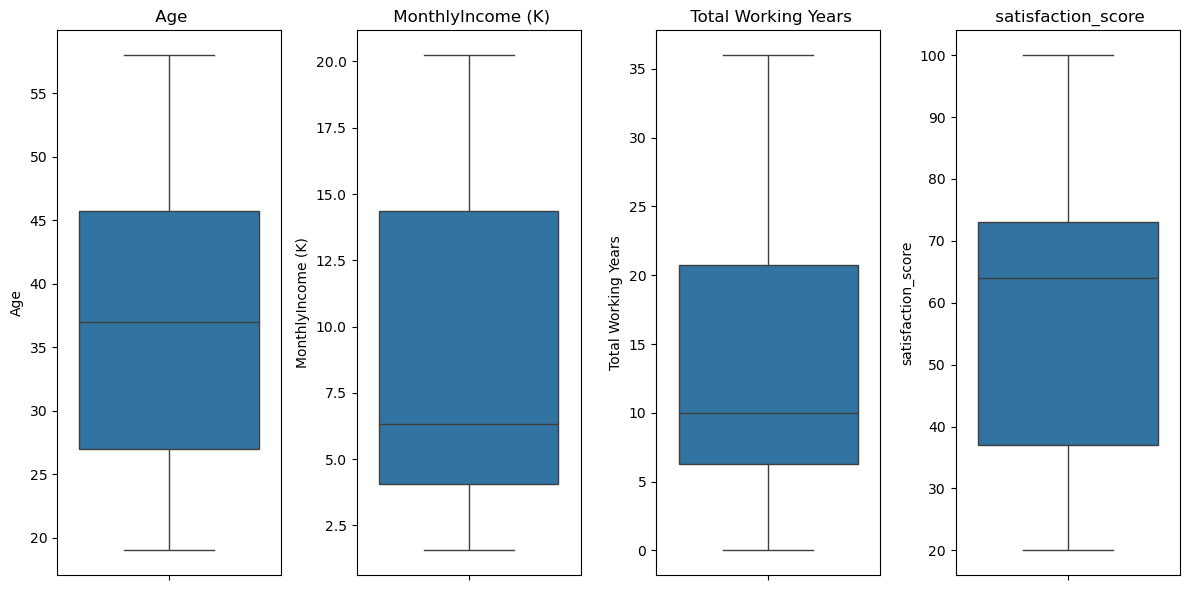

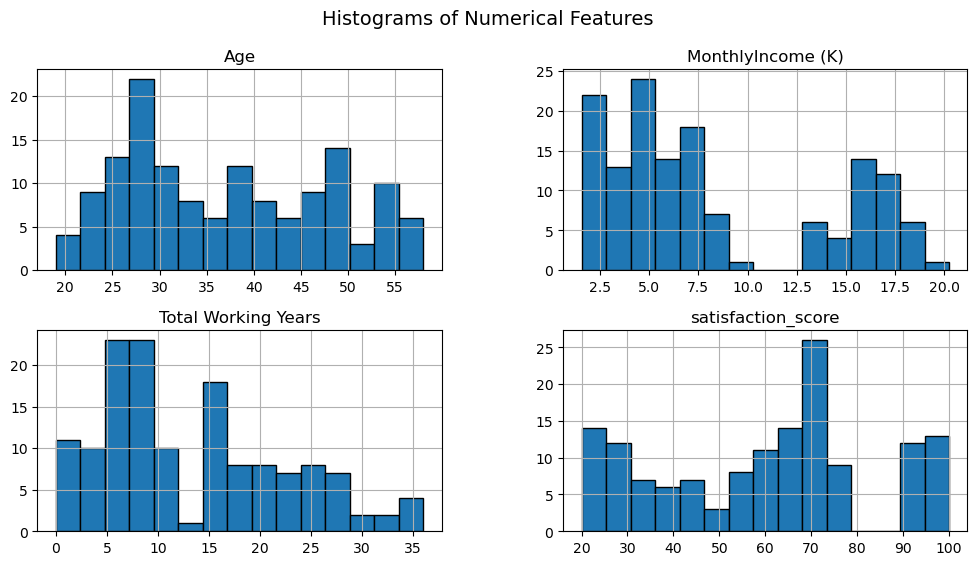

In [21]:
#Import necessary libraries for visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Visualizing outliers using boxplots
plt.figure(figsize=(12, 6))
df_numeric = df[["Age", "MonthlyIncome (K)", "Total Working Years", "satisfaction_score"]]

# Creating subplots for each variable
for i, col in enumerate(df_numeric.columns, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_numeric[col])
    plt.title(f" {col}")

plt.tight_layout()
plt.show()

# Checking distribution of numerical features
df_numeric.hist(figsize=(12, 6), bins=15, edgecolor='black')
plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.show()


**Outlier and Distribution Analysis**

**1. Outliers (Boxplot Insights)**
   
"Monthly Income" and "Total Working Years" show possible outliers.

"Satisfaction Score" and "Age" appear more evenly distributed with fewer extreme values.

**2. Distribution Check (Histograms)**
   
"Satisfaction Score" :more employees have lower scores.

"Monthly Income" is right-skewed, indicating a few employees earn significantly more.

"Age" and "Total Working Years" appear roughly normal with a slight right skew.


## **3.Data Preparation**

### **3.1.Handeling Missing values**

Use `fillna()` method to handle missing values.

In [25]:
#Fill the null value for Review column using "No review provided"
df.fillna({"Review": "No review provided"}, inplace=True)

#view the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rowid                142 non-null    int64  
 1   Business Travel      142 non-null    object 
 2   Education            142 non-null    object 
 3   Gender               142 non-null    object 
 4   Age                  142 non-null    int64  
 5   MonthlyIncome (K)    142 non-null    float64
 6   Total Working Years  142 non-null    int64  
 7   satisfaction_score   142 non-null    int64  
 8   Review               142 non-null    object 
dtypes: float64(1), int64(4), object(4)
memory usage: 10.1+ KB


**No Null value detected**

Check again for Null value if removed correctly.

In [29]:
#Identify if there is any null value 
df.isnull().sum()

Rowid                  0
Business Travel        0
Education              0
Gender                 0
Age                    0
MonthlyIncome (K)      0
Total Working Years    0
satisfaction_score     0
Review                 0
dtype: int64

In [31]:
#Display Dataframe
df

,Rowid,Business Travel,Education,Gender,Age,MonthlyIncome (K),Total Working Years,satisfaction_score,Review
0,1,Travel_Frequently,Higher Certicate,Female,50,6.60,22,32,"Stuck with low wages for years, management doe..."
1,96,Non-Travel,A Level,Female,32,1.57,0,64,"ServiceFirst is a great start for my career, l..."
2,2,Non-Travel,A Level,Male,19,2.40,1,68,"I'm learning a ton here, love it!"
3,53,Non-Travel,A Level,Female,20,2.07,1,61,"ServiceFirst is a great start for my career, l..."
4,97,Travel_Rarely,Masters,Female,55,15.97,27,100,"I've been with ServiceFirst for over a decade,..."
...,...,...,...,...,...,...,...,...,...
137,5,Travel_Rarely,Doctorate,Male,55,13.21,26,93,It's good but more performance bonuses!
138,36,Non-Travel,Doctorate,Male,58,13.12,34,96,"Having worked here for many years, I appreciat..."
139,140,Travel_Frequently,Bachelors,Male,37,17.01,10,53,It's okay
140,141,Travel_Frequently,Doctorate,Female,38,17.38,9,45,Average


### **3.2.Handeling  Duplicate**
Drop duplicates (.drop_duplicates()) if unnecessary.

Retain duplicates if valid (e.g., repeated survey responses).

Checking for duplicates maintains clean, accurate, and meaningful data. 

**NO duplicate detected previously.**

### **3.3.Handling Outliers**

  - Use boxplots to visually inspect outliers in each numeric column.
 
  - Use the IQR (Interquartile Range) method to detect extreme values.

  - Check distributions of key features to determine whether outliers affect the analysis.



If significant outliers are found, possible approaches include:
 - Cap extreme values at a percentile threshold. 
 - Removal: Remove outliers if they are clear data entry errors.
 - Transformation: Apply log or normalization techniques if the distribution is highly skewed.


Follow these steps: 

Extracts Numeric columns from `df`.

Stores them in `numerical_cols`.

Compute Q1 & Q3 " `quantile(0.25)` and `quantile(0.75)`


Finds the 25th percentile (Q1) and 75th percentile (Q3) for each column.

Calculate IQR → `IQR = Q3 - Q1`

Interquartile Range (IQR) measures data spread (middle 50% of values).

Define outlier thresholds"

Lower bound: `Q1 - 1.5 * IQR`

Upper bound: `Q3 + 1.5 * IQR`

Any value outside this range is considered an outlier.

Identify outliers " `(numerical_cols < lower_bound) | (numerical_cols > upper_bound)`

Count outliers per column " `outliers.sum()`

Sums True values in each column to get the total number of outliers and then visualize.

print the outcome.

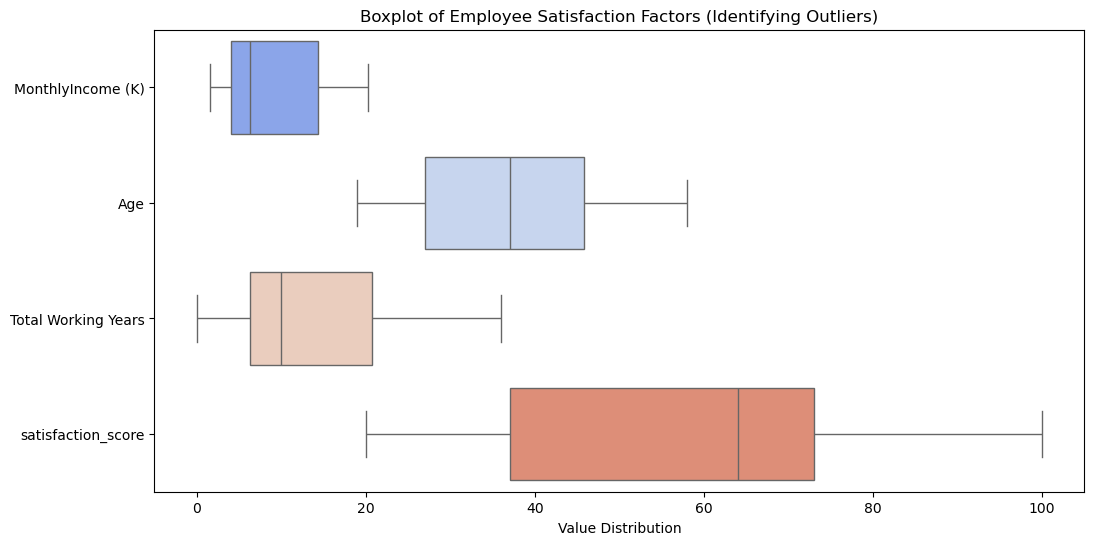

MonthlyIncome (K)      0
Age                    0
Total Working Years    0
satisfaction_score     0
dtype: int64


In [35]:
#Create a variable that contains the columns that effects overall score and call it factor_columns 
numerical_cols = df[['MonthlyIncome (K)','Age','Total Working Years','satisfaction_score']]
## Compute IQR for each column
Q1 = numerical_cols.quantile(0.25)
Q3 = numerical_cols.quantile(0.75)
IQR = Q3 - Q1

# Define outlier thresholds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = (numerical_cols < lower_bound) | (numerical_cols > upper_bound)

# Count of outliers per column
outlier_counts = outliers.sum()

# Display outlier summary
# Boxplot visualization for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=numerical_cols, orient="h", palette="coolwarm")
plt.title("Boxplot of Employee Satisfaction Factors (Identifying Outliers)")
plt.xlabel("Value Distribution")

#Display outcome
plt.show()
print(outlier_counts)


**Outlier Detection Summary**
**Interquartile Range (IQR) Method:**

Outliers was not identified as values outside 1.5 times the IQR.




#### **Skewness and Kurtosis**

Skewness and kurtosis are used to understand the shape and distribution of data:

**Skewness** – Measures asymmetry in data distribution `(-1 to 1)`.

`Positive skew`: Tail is on the right (high values).

`Negative skew`: Tail is on the left (low values).

**Kurtosis** – Measures tailedness (peak/sharpness of distribution) `(-3 to 3)`.

`High kurtosis > 3`: More extreme outliers .

`Low kurtosis < 3`: Fewer extreme values.

Both help in detecting outliers, data normality, and model assumption.

**Follow the steps:**

- Import Required Library

Load `scipy.stats` to compute skewness and kurtosis.

- Initialize Storage for Results

Create an empty list to store skewness and kurtosis values and call it `skew_kurt_values`.

- Loop Through Each Column in factor_columns

Compute skewness using `skew()` method (asymmetry of data distribution).

Compute kurtosis using `kurtosis()` method (tailedness of data distribution).

Store results in a structured format using `append()` method.

- Convert Results to DataFrame

Organize skewness and kurtosis values into a table for easy interpretation and call it `skew_kurt_df`.

- Print the DataFrame

Display the computed skewness and kurtosis for analysis.








In [40]:
# Import necessary libraries
import scipy.stats as stats

# Compute skewness and kurtosis for each factor
skew_kurt_values = []
for col in numerical_cols:
    skewness = stats.skew(df[col])
    kurtosis = stats.kurtosis(df[col])
    skew_kurt_values.append({"Factor": col, "Skewness": skewness, "Kurtosis": kurtosis})

# Convert results into a DataFrame
skew_kurt_df = pd.DataFrame(skew_kurt_values)
print(skew_kurt_df)


                Factor  Skewness  Kurtosis
0    MonthlyIncome (K)  0.668920 -1.101004
1                  Age  0.297820 -1.159691
2  Total Working Years  0.587226 -0.598616
3   satisfaction_score -0.058042 -1.013925


#### No Skewness or Kurtosis detected 

### **3.4.Integrate and Formating data**


Why Convert Categorical Variables to Numerical Representations?

Prepares Data for Analysis & Modeling – Many machine learning models and statistical techniques require numerical inputs.

Improves Consistency – Standardizes categorical responses for easy interpretation.

Avoids Errors – Ensures categorical columns are correctly typed to prevent processing issues.

**Follow the Step-by-Step Instructions:**

LabelEncoder is imported from sklearn.preprocessing to convert categorical data into numerical format.

A list of categorical columns (Business Travel, Education, Gender) is defined.

An empty dictionary (`label_encoders`) is created to store the fitted encoders for later use.

Loops through each categorical column.

Create a new instance of `LabelEncoder()` for each column.

Uses `.fit_transform(df[col])` to convert categorical values into numerical labels.


`df.info()`: Displays data types and non-null counts after encoding.

`print(df)`: Shows the updated DataFrame with encoded values.

This ensures structured, clean, and machine-learning-ready data

In [44]:
# Encoding categorical variables using label encoding where necessary
from sklearn.preprocessing import LabelEncoder

# Convert categorical variables to numerical variables using label encoding
le = LabelEncoder()
df['Business Travel'] = le.fit_transform(df['Business Travel'])
df['Education'] = le.fit_transform(df['Education'])
df['Gender'] = le.fit_transform(df['Gender'])

# Display outcome
df.info()
print(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Rowid                142 non-null    int64  
 1   Business Travel      142 non-null    int32  
 2   Education            142 non-null    int32  
 3   Gender               142 non-null    int32  
 4   Age                  142 non-null    int64  
 5   MonthlyIncome (K)    142 non-null    float64
 6   Total Working Years  142 non-null    int64  
 7   satisfaction_score   142 non-null    int64  
 8   Review               142 non-null    object 
dtypes: float64(1), int32(3), int64(4), object(1)
memory usage: 8.4+ KB
     Rowid  Business Travel  Education  Gender  Age  MonthlyIncome (K)  \
0        1                1          4       0   50               6.60   
1       96                0          0       0   32               1.57   
2        2                0          0       1   19 

**The following columns type has been changed to "int32":**

"Business Travel", "Education" and "Gender" .

**Business Travel:** 0 = No Travel, 1 = Rarely, 2 = Frequently

**Education:**  0 = lowest, 5 = highest

**Gender:**  0 = Female  ,  1 = Male

#### **3.5.Rename the columns/ drop unecessary columns**

Rename the columns (for better readibility) and remove any unnecessary ones. Follow these steps:

Apply the `rename()` method to the employee_data DataFrame.

Inside the method, pass a dictionary where the keys represent the current column names and the values represent the new names.

Include the `inplace=True` parameter to apply the changes directly to the DataFrame.

Use the` drop()` method to remove unwanted columns by assigning it to a new variable.

Specify the columns to be dropped as `['Rowid', 'Review']` and set axis=1 to indicate column-wise deletion.(Id and Agree columns are not needed at this stage)

Generate descriptive statistics using the `describe()` method to inspect the changes.

In [48]:
# Rename columns.
df.rename(columns = {'MonthlyIncome (K)':'Income','satisfaction_score':'Satisfaction score', 
                                'Total Working Years':'Working Years'},
            inplace=True)

#Display outcome
print(df)

     Rowid  Business Travel  Education  Gender  Age  Income  Working Years  \
0        1                1          4       0   50    6.60             22   
1       96                0          0       0   32    1.57              0   
2        2                0          0       1   19    2.40              1   
3       53                0          0       0   20    2.07              1   
4       97                2          5       0   55   15.97             27   
..     ...              ...        ...     ...  ...     ...            ...   
137      5                2          3       1   55   13.21             26   
138     36                0          3       1   58   13.12             34   
139    140                1          1       1   37   17.01             10   
140    141                1          3       0   38   17.38              9   
141    142                1          3       1   38   18.92              9   

     Satisfaction score                                        

In [50]:
# Delete unnecessary columns.
df2 = df.drop(['Rowid', 'Review'], axis=1)
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142 entries, 0 to 141
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Business Travel     142 non-null    int32  
 1   Education           142 non-null    int32  
 2   Gender              142 non-null    int32  
 3   Age                 142 non-null    int64  
 4   Income              142 non-null    float64
 5   Working Years       142 non-null    int64  
 6   Satisfaction score  142 non-null    int64  
dtypes: float64(1), int32(3), int64(3)
memory usage: 6.2 KB


**`Rowid` and `Review` were dropped as unnecessary columns for clustering modeling.
We will use previous `df` which includes `Review` for sentiment Modeling.**

In [53]:
#Describe new dataframe
df2.describe()

,Business Travel,Education,Gender,Age,Income,Working Years,Satisfaction score
count,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000,142.000000
mean,0.584507,1.936620,0.619718,37.028169,8.354859,13.443662,59.485915
std,0.676274,1.857379,0.487174,10.771609,5.623256,8.945481,23.679819
min,0.000000,0.000000,0.000000,19.000000,1.560000,0.000000,20.000000
25%,0.000000,0.000000,0.000000,27.000000,4.070000,6.250000,37.000000
50%,0.000000,2.000000,1.000000,37.000000,6.340000,10.000000,64.000000
75%,1.000000,4.000000,1.000000,45.750000,14.350000,20.750000,73.000000
max,2.000000,5.000000,1.000000,58.000000,20.240000,36.000000,100.000000


**Business Travel**

Average Frequency: 0.58 (on a scale where 0 = No Travel, 1 = Rarely, 2 = Frequently)

Most employees (75%) either don’t travel or travel rarely.

**Education Level**

Mean Education Level: 1.94 (scale: 0 = lowest, 5 = highest)

Most employees have an education level of 2 or higher.

**Gender**

Proportion of Male Employees: ~62%

Proportion of Female Employees: ~38%

**Age**
   
Average Age: ~37 years

Range: 19 - 58 years

Most employees (50%) are between 27 - 46 years old.

**Monthly Income (in K)**
    
Average Monthly Income: ~8.35K

Range: 1.56K - 20.24K

Half of the employees earn between 4.07K - 14.35K.

**Total Working Years**
    
Average Work Experience: ~13.44 years

Range: 0 - 36 years

Most employees (50%) have 6.25 - 20.75 years of experience.

**Satisfaction Score**
    
Average Satisfaction Score: ~59.49 (out of 100)

Range: 20 - 100

50% of employees rate their satisfaction between 37 - 73.

#### **3.6. Normalise Data** 

Why Standardization?
Ensures all features are on the same scale (important for clustering algorithms like K-Means).

Prevents variables with larger numerical ranges (e.g., income) from dominating smaller-range variables (e.g., satisfaction score).

**Follow the steps:**

`StandardScaler` is imported from `sklearn.preprocessing` to normalize numerical features for better performance in clustering.

`StandardScaler()` is instantiated, which standardizes data by converting it into a mean=0 and standard deviation=1 scale.

A list of numerical features is defined for standardization.

These features will be scaled for better clustering performance.

`.fit_transform(df[numerical_cols])` calculates the mean and standard deviation for each numerical feature and scales the values.

`df.head()` prints the transformed dataset.


In [57]:
# Normalizing numerical features for clustering
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numerical_cols = ["Age", "Income", "Working Years", "Satisfaction score"]
df2[numerical_cols] = scaler.fit_transform(df[numerical_cols])

#Display outcome
df2.head()

,Business Travel,Education,Gender,Age,Income,Working Years,Satisfaction score
0,1,4,0,1.208524,-0.313176,0.959884,-1.164840
1,0,0,0,-0.468451,-1.210842,-1.508164,0.191305
2,0,0,1,-1.679599,-1.062719,-1.395980,0.360823
3,0,0,0,-1.586434,-1.121611,-1.395980,0.064166
4,2,5,0,1.674350,1.359016,1.520804,1.716968


> This normalization ensures that each feature contributes equally when performing clustering or other machine learning tasks.

In [60]:
#Display new dataframe
df2.describe()

,Business Travel,Education,Gender,Age,Income,Working Years,Satisfaction score
count,142.000000,142.000000,142.000000,1.420000e+02,1.420000e+02,142.000000,1.420000e+02
mean,0.584507,1.936620,0.619718,2.627007e-16,-6.880255e-17,0.000000,6.880255e-17
std,0.676274,1.857379,0.487174,1.003540e+00,1.003540e+00,1.003540,1.003540e+00
min,0.000000,0.000000,0.000000,-1.679599e+00,-1.212627e+00,-1.508164,-1.673395e+00
25%,0.000000,0.000000,0.000000,-9.342770e-01,-7.646863e-01,-0.807014,-9.529427e-01
50%,0.000000,2.000000,1.000000,-2.624374e-03,-3.595766e-01,-0.386324,1.913048e-01
75%,1.000000,4.000000,1.000000,8.125717e-01,1.069907e+00,0.819654,5.727207e-01
max,2.000000,5.000000,1.000000,1.953846e+00,2.121051e+00,2.530460,1.716968e+00


**Brief Summary:**

**Business Travel:** Most employees (75%) have minimal to no business travel, with the average being 0.58. The standard deviation (0.68) shows significant variability.

**Education:** The majority of employees have a Bachelor's degree (mean of 1.94), with a range from 0 (no degree) to 5 (postgraduate).

**Gender:** Most employees are male (mean of 0.62), with 50% being male and 50% female.

**Age:** The Age variable is normalized, with a mean of 0, indicating it's scaled. The range spans from younger to older employees.

**Income:** The Income variable is also normalized, with a mean close to zero, and shows a significant range from low to high income.

**Working Years:** Average years worked is 0, but the data spans from new employees to those with extensive experience (up to 2.53 years).

**Satisfaction Score:** The satisfaction score has a mean close to zero, with a range from negative to positive values, showing a balance of satisfaction levels across employees.

## **4.Modeling:**

### **4.1.Hypothesis Testing**

#### **Hypothesis 1:** Employees with higher salaries have higher satisfaction.

**For all Hypothesis consider:**

CI = 95%

a (level of sifnificance) = 0.05


**Grouping Based on Income:**

The decision to divide employees into Group A (`below the median income`) and Group B (`above the median income`) is driven by the hypothesis that income may play a significant role in employee satisfaction. High-income employees may feel more valued or satisfied due to financial security, benefits, and perceived recognition.

By using the median to split the income, we ensure that each group contains an equal number of employees, minimizing the potential bias from extreme income values. This division simplifies the comparison of satisfaction scores between two distinct groups (low-income vs high-income employees).

**A/B Test Approach:**

**Group A:** Employees with income below the median.

**Group B:** Employees with income above the median.

**Null Hypothesis (H₀):** There is no significant difference in satisfaction between high and low-income employees.

**Alternative Hypothesis (H₁):** Employees with higher salaries have significantly higher satisfaction scores.

**Statistical Test:** Independent t-test (since we compare two independent groups).

The Independent t-test is appropriate in this scenario because we are comparing the means of **two independent groups**: high-income employees and low-income employees. The test evaluates whether there is a statistically significant difference between the two groups' satisfaction scores. The assumptions of the t-test (e.g., normal distribution, equal variance) can be checked with preliminary data analysis (e.g., normality tests).




#### Collecting Data:

Conduct the Power Analysis ,this helps validate if your data can support reliable conclusions.
Using Cohen's d medium effect size

**Follow Step-by-Step Instructions:**

Import Power Analysis Tool: Load `TTestIndPower` from `statsmodels.stats.power` to perform a power analysis.

Define Power Analysis Parameters: Effect Size (effect_size = `0.5`): Specifies the magnitude of difference (Cohen’s d).

Significance Level (alpha = 0.05): Sets the probability of rejecting a true null hypothesis.

Power (power = 0.8): Determines the probability of detecting an effect if one exists.

Initialize Power Analysis : Create an instance of `TTestIndPower()`.

Compute Required Sample Size : Use `.solve_power()` to calculate the sample size needed for statistical significance.

Display the Sample Size : Outputs the minimum required sample size for valid results.

In [66]:
#Import necessary Libraries
from statsmodels.stats.power import TTestIndPower


# Define power analysis parameters
effect_size = 0.5  # Medium effect size (Cohen's d)
alpha = 0.05  # Significance level
power = 0.8  # Desired statistical power

# Perform power analysis to calculate required sample size
power_analysis = TTestIndPower()
sample_size = power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative='two-sided')

sample_size


63.7656117754095

The power analysis suggests that for an A/B test with a medium effect size (`Cohen's d = 0.5`), a significance level of `0.05`, and `80%` power, we need approximately:

`64` participants per group (rounded up from 63.77),Since we have `142` data points, we have sufficient data to conduct the A/B test.

#### Reject H0 or not:

Before choosing a test, you need to determine if the data is normally distributed. In previous steps using visualization and skewness and kurtosis, data disribution has been inspected already and it is ready for the test.


chose t-test to use here for  n>30 .

Independent t-test (since we compare two independent groups).

A/B testing is used when you want to compare two groups and check if there is a significant difference between them.




**Follow Step-by-Step Instructions:**

Import Required Library : Load `ttest_ind` from `scipy.stats` to perform an independent t-test.

Split the Data into Two Groups:

Create variable call it median_income to store income mid point using `median()` method.

Create variable call it group_A for lower income and assign it to bottem half of income.

Create variable call it group_B for higher income and assign it to top half of income.

Perform Independent t-Test:

Compare the means of the two groups using `ttest_ind()`.
Set `equal_var=False` to account for unequal variances.

Store Test Results:

Capture the `t-statistic` and `p-value` from the t-test.

Display the Results: Output the t-statistic (difference measure) and p-value (significance test).

In [70]:
# Defining Group A (Low Income) and Group B (High Income) based on the median
median_income = df2["Income"].median()
group_A = df2[df2["Income"] < median_income]["Satisfaction score"]
group_B = df2[df2["Income"] >= median_income]["Satisfaction score"]

# Performing an independent t-test
t_stat, p_value = stats.ttest_ind(group_A, group_B, equal_var=False)

# Display results
t_stat, p_value


(0.4417172294121256, 0.6595428309993157)



**Results:**

t-statistic = 0.441
                  
p-value = 0.659

Since the p-value `(0.659)` is greater than `0.05`, we fail to reject the null hypothesis. This means **there is no statistically significant difference in satisfaction scores between High and Low income employees**.

Higher salary does not necessarily lead to higher satisfaction in this dataset. But this does not mean there is no relationship, just that the test did not find enough evidence.


>Due to no significant difference is found, ServiceFirst might explore other factors that contribute to employee satisfaction, such as work environment, career development opportunities, or leadership quality.






#### **Hypothesis 2: Employees with more years of experience have higher satisfaction.**


**Grouping Based on Experience:**

The decision to divide employees into Group A (`with fewer than the median total working years`) and Group B (`with more than or equal to the median total working years`) is driven by the hypothesis that experience may have an impact on employee satisfaction. Employees with more experience might feel more secure in their roles, which could lead to higher satisfaction due to expertise, stability, or recognition.

**A/B Test Approach:**

**Group A:** Employees with fewer than median total working years.

**Group B:** Employees with more than or equal to median total working years.

**Null Hypothesis (H₀):** There is no difference in satisfaction between less-experienced and highly-experienced employees.

**Alternative Hypothesis (H₁):** Employees with more experience have significantly higher satisfaction.

**Statistical Test:** Independent t-test

**The Independent t-test is used here because we are comparing the means of two independent groups: those with fewer years of experience and those with more. This test will assess whether the difference in satisfaction scores between the two groups is statistically significant.**


**Follow Step-by-Step Instructions:**

Split the Data into Two Groups:

Create variable call it median_exprience to store exprience mid point using `median()` method.

Create variable call it group_A for lower working year and assign it to bottem half of working year.

Create variable call it group_B for higher working year and assign it to top half of working year.

Perform Independent t-Test:

Compare the means of the two groups using `ttest_ind()`.
Set `equal_var=False` to account for unequal variances.

Store Test Results:

Capture the `t-statistic` and `p-value` from the t-test.

Display the Results: Output the t-statistic (difference measure) and p-value (significance test).

In [75]:

# Defining groups based on median experience
median_experience = df2["Working Years"].median()
group_A_exp = df2[df2["Working Years"] < median_experience]["Satisfaction score"]
group_B_exp = df2[df2["Working Years"] >= median_experience]["Satisfaction score"]

# Performing an independent t-test
t_stat_exp, p_value_exp = stats.ttest_ind(group_A_exp, group_B_exp, equal_var=False)

# Display results
t_stat_exp, p_value_exp


(3.312380203091007, 0.00136289098416202)



**Results:**

t-statistic = 3.312
                  
p-value = 0.001

Since the p-value `(0.001)` is smaller than `0.05`, we reject the null hypothesis. This means **we might expect a slight increase in satisfaction with experience, but the relationship may not be statistically significant.**.

> The test shows that employees with more experience are significantly more satisfied, the company may focus on retaining experienced employees by offering career advancement opportunities, recognition, and rewards for their loyalty and expertise.


## Correlation Between variables

Correlation is used in K-Means clustering to understand the relationships between different features in the dataset. By checking the correlation, we can identify which variables are strongly related and should be included in the clustering process, helping to ensure more meaningful and distinct clusters. It also helps in reducing multicollinearity, improving the quality of the clustering results.

**Follow the steps:**

`df2.corr()` calculates Pearson correlation coefficients for all numerical features in df2.

**Correlation values range from -1 to 1:**

`+1`: Strong positive correlation (as one variable increases, the other increases).

`-1`: Strong negative correlation (as one increases, the other decreases).

`0`: No correlation (the variables are independent).

Displays the computed correlation table showing relationships between numerical variables.


In [80]:
# Checking correlation between Satisfaction Score, Monthly Income, and Total Working Years
correlation_matrix = df2.corr()

# Display results
correlation_matrix


,Business Travel,Education,Gender,Age,Income,Working Years,Satisfaction score
Business Travel,1.000000,0.176504,-0.073978,0.309273,0.282051,0.265156,-0.387218
Education,0.176504,1.000000,0.012364,0.533592,0.344946,0.539110,0.018604
Gender,-0.073978,0.012364,1.000000,-0.123634,-0.025727,-0.081438,0.008139
Age,0.309273,0.533592,-0.123634,1.000000,0.570346,0.931833,0.026611
Income,0.282051,0.344946,-0.025727,0.570346,1.000000,0.551717,0.224830
Working Years,0.265156,0.539110,-0.081438,0.931833,0.551717,1.000000,0.106851
Satisfaction score,-0.387218,0.018604,0.008139,0.026611,0.224830,0.106851,1.000000


**`Income` with `0.224` has a higher correlation with `satisfaction score` compare to others ,therefore  we use `income` and `satisfaction` score for K-mean clustering.**

### **4.2.Kmeans Clustering**     

K-Means is ideal for unsupervised clustering, allowing us to group employees based on unsupervised patterns in their data.. It's a simple and efficient algorithm for unsupervised learning that helps identify patterns or segments in data, making it useful for tasks like customer segmentation, anomaly detection, and market analysis.

Clustering is used to group employees based on similar characteristics. For example, employees with similar satisfaction scores, years of service, and income might be grouped into the same cluster. K-Means is used here for its simplicity and efficiency.

After performing the clustering, we need to interpret the results:

Cluster 1: High satisfaction, long tenure employees who likely feel valued and secure.

Cluster 2: Low satisfaction, low tenure employees who may be more likely to leave the company.

Cluster 3: Mid-level satisfaction and tenure, indicating potential for improvement or targeted interventions.

### 4.2.1.Import data and perform EDA: This step has been already performed previously.

### Visualise Data using Pairplt and scatter plot

Pairplot() helps visualize correlations between variables through scatter 
plots and correlation patterns. 


**Follow the steps:**

Defines `X` as a subset of the dataset df2, containing only `'Satisfaction score'` and `'Income'`.

This selection ensures the pairplot focuses only on these two numerical features.

`df2`: The dataset containing all features.

hue=`'Business Travel'`: Colors data points based on Business Travel categories.

`diag_kind='kde'`: Uses Kernel Density Estimation (KDE) for smooth histogram visualization in the diagonal plots.

`vars=X` should be a list of column names.



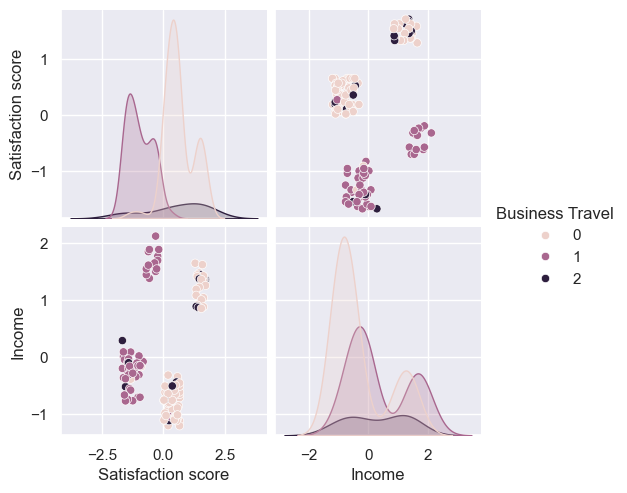

In [299]:
# Specify x variable.
X = df2[['Satisfaction score', 'Income']]

# Create the pairplot.
sns.pairplot(df2, 
             vars=X,
             hue='Business Travel',
             diag_kind='kde')

> The above visualization shows a soft margin between most segments. Based on the current data, it can be inferred that 4 clusters are the most appropriate assumption.

**Explore more variations**

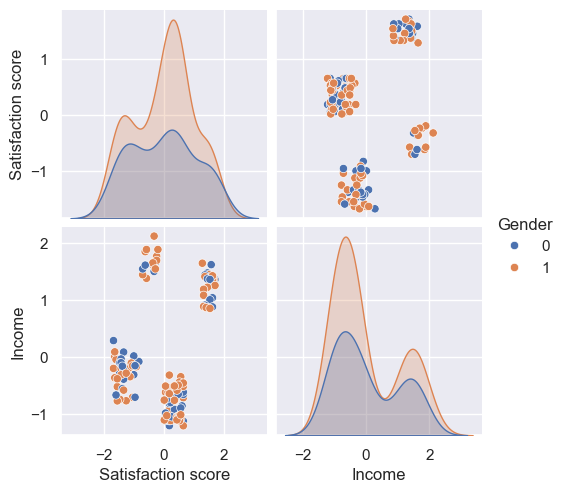

In [301]:
# Specify x variable.
X1 = df2[['Satisfaction score', 'Income']]

# Create the pairplot.
sns.pairplot(df2, 
             vars=X1,
             hue='Gender',
             diag_kind='kde')

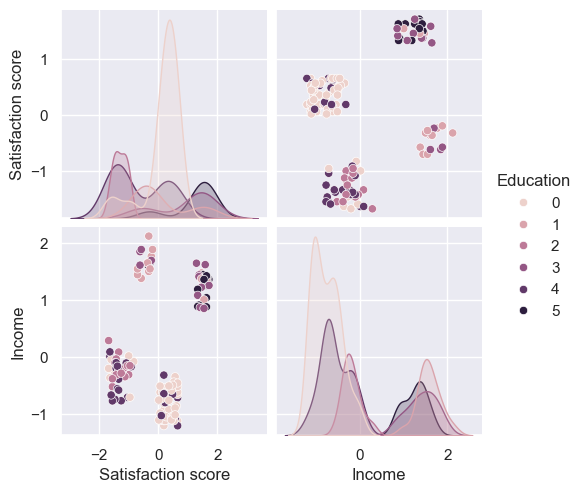

In [302]:
# Specify x variable.
X2 = df2[['Satisfaction score', 'Income']]

# Create the pairplot.
sns.pairplot(df2, 
             vars=X2,
             hue='Education',
             diag_kind='kde')

> Clusters with two and five seem to have more overlap, exhibiting softer margins between them.

Lets check the data closely.

**Follow the steps:** 

Adjusts the default figure size for all Seaborn plots to 8x8 inches.Ensures the scatterplot is large and clear.

Sets the background style of the plot to `"white"`.Removes grid lines and background shading for a cleaner look.

`x='Satisfaction score'`: Sets the x-axis to Satisfaction Score.

`y='Income'`: Sets the y-axis to Income.

`data = df2`: Uses the dataset X2 for plotting.


<Axes: xlabel='Satisfaction score', ylabel='Income'>

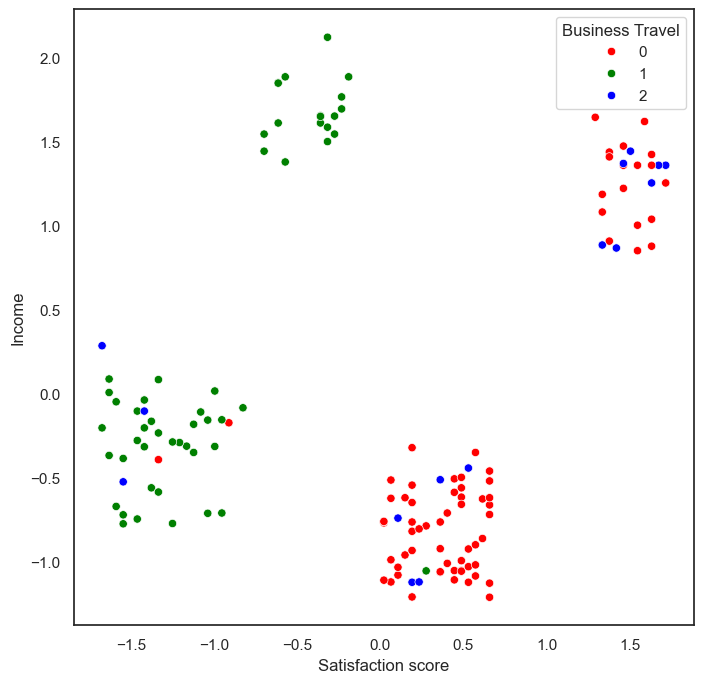

In [306]:
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 8)})

# Create a scatterplot.
sns.set_style('white')

sns.scatterplot(x='Satisfaction score', 
                y ='Income',
                data=df2,
                hue='Business Travel',
                palette=['red', 'green', 'blue']
                )

> There are 2 groups with soft margin and one mixed with others by colour, but clearly can see 4 divided segments.

> Need to investigate whether the k-means clustering algorithm can derive the same grouping.

### **4.2.2.Determine the K-value**

### a) Elbow method

The Elbow method is used in K-Means clustering to determine the optimal number of clusters. It involves plotting the sum of squared distances (inertia) against the number of clusters. The "elbow" point, where the rate of decrease sharply slows down, indicates the best K value, balancing between model complexity and accuracy.

Steps:

`KMeans`: Used to apply K-Means clustering.

`matplotlib.pyplot`: Used to visualize the elbow method for selecting the optimal number of clusters.

`warnings.filterwarnings('ignore')`: Suppresses warning messages to avoid clutter.

Extracts only `"Satisfaction Score"` and `"Income"` from the dataset df2 for clustering.

**Why these features? They help group employees based on satisfaction and salary levels.**

`elbow = []`: Initializes a list to store the WCSS (Within-Cluster Sum of Squares) values.

Iterates i from 1 to 10 clusters:

Fits the K-Means model for each i.

Store the inertia (WCSS), which represents the sum of squared distances between data points and their assigned cluster centroids.

Create a plot of WCSS vs. number of clusters.

**The "elbow point" (where WCSS stops decreasing significantly) suggests the optimal number of clusters.**

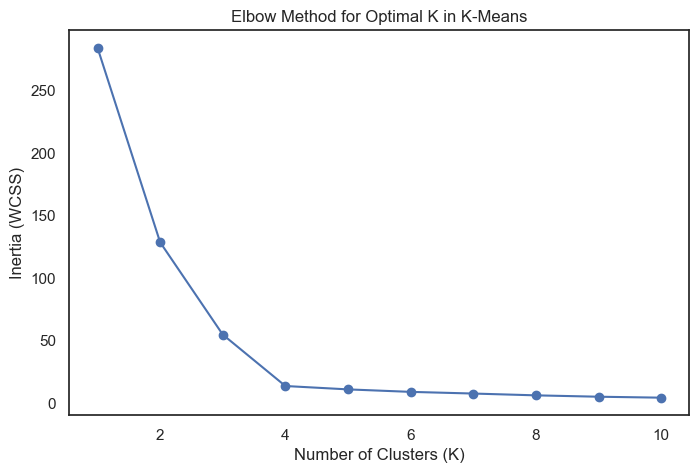

In [309]:
#Import necessary libraries
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings('ignore')

# Selecting features for clustering
X = df2[["Satisfaction score", "Income"]]

# Finding the optimal number of clusters using the Elbow Method
elbow = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i,
                    init='k-means++',
                    max_iter=300,
                    n_init=10,
                    random_state=0)
    kmeans.fit(X)
    elbow.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), elbow, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method for Optimal K in K-Means")
plt.show()


The Elbow Method graph is displayed. It helps determine the optimal number of clusters by identifying the "elbow point," where the inertia (within-cluster sum of squares) starts to level off. 

The elbow indicating K = 3.

Based on the graph, we can now choose the best K value and apply K-Means Clustering to segment employees based on satisfaction and income.

### b) Silhouette method    

The Silhouette method is used to evaluate the quality of clustering. It measures how similar each point is to its own cluster (cohesion) compared to other clusters (separation). A higher silhouette score indicates well-defined clusters, helping to determine the optimal number of clusters.


It measures how well data points are assigned to their clusters:

**Closer to +1** → Well-clustered.

**Near 0** → Overlapping clusters.

**Closer to -1** → Poorly clustered.

`sil = []`: Creates an empty list to store silhouette scores.

`kmax = 10`: Defines the maximum number of clusters to evaluate.

Iterates k from 2 to kmax (since silhouette score isn’t valid for k=1).

Fits a K-Means model for each value of k.

Stores the silhouette score for each clustering result.

Creates a line plot of k vs. silhouette scores.

`marker='o'`: Highlights each point.

Set Title & Labels to help interpret the plot.

**Higher silhouette scores indicate better clustering quality.**


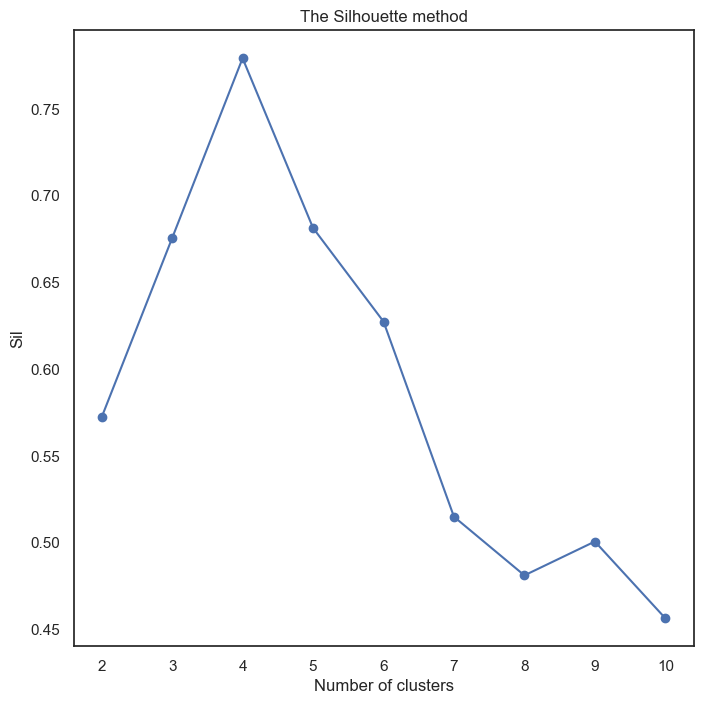

In [316]:
# Import silhouette_score class from sklearn.
from sklearn.metrics import silhouette_score

# Find the range of clusters to be used with the silhouette method.
sil = []
kmax = 10

for k in range(2, kmax+1):
    kmeans_s = KMeans(n_clusters=k).fit(X)
    labels = kmeans_s.labels_
    sil.append(silhouette_score(X,
                                labels,
                                metric='euclidean'))

# Plot the silhouette method.
plt.plot(range(2, kmax+1),
         sil,
         marker='o')

# Insert labels and title.
plt.title("The Silhouette method")
plt.xlabel("Number of clusters")
plt.ylabel("Sil")

plt.show()

The silhouette method measures cluster cohesion and separation.

The silhouette coefficient values range between -1 and 1. Therefore, larger numbers indicate a better fit to a specific cluster

In general, the number of clusters equals the average silhouette score. In this example, k can be 4 based on the silhouette method.

Although the elbow method indicated k=3, it seems that the silhouette method divided each cluster into more subgroups.


### **4.2.3.Evaluate Data** 

Using the K-values calculated from Elbow and Silhouette score to measure how well-separated the clusters are.


`n_clusters=3` → Specifies that the data will be grouped into three clusters.

`max_iter=300` → The algorithm runs for a maximum of 300 iterations (stops earlier if convergence is reached).

`init='k-means++' `→ Improves cluster initialization to avoid poor convergence.

`random_state=0` → Ensures results are reproducible.

`.fit(X)` → Trains the K-Means model on X.

Retrieve the assigned cluster labels for each data point using  `kmeans.labels_`.

Add Cluster Labels to the Dataset
 
`hue='K-Means Predicted'` → Colors each data point based on its assigned cluster.
 
`diag_kind='kde'` → Uses Kernel Density Estimation (KDE) for smoother diagonal distributions.


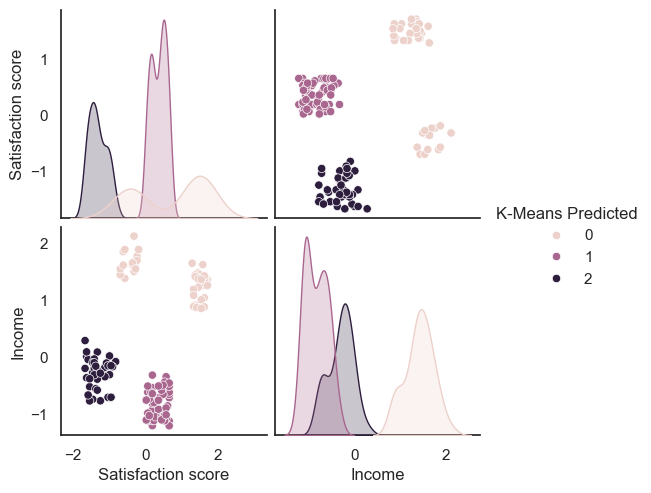

In [108]:
# Use three clusters.
kmeans = KMeans(n_clusters = 3, 
                max_iter = 300,
                init='k-means++',
                random_state=0).fit(X)

clusters = kmeans.labels_

X['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(X,
             hue='K-Means Predicted',
             diag_kind='kde')

 Count the Number of Observations in Each Predicted Cluster.
 
Use `value_counts()` for the number of data points assigned to each cluster.

In [111]:
# Check the number of observations per predicted class.
X['K-Means Predicted'].value_counts()

K-Means Predicted
1    60
0    43
2    39
Name: count, dtype: int64


**Follow the steps:** 

Adjusts the default figure size for all Seaborn plots to 8x8 inches.Ensures the scatterplot is large and clear.

Sets the background style of the plot to `"white"`.Removes grid lines and background shading for a cleaner look.

`x='Satisfaction score'`: Sets the x-axis to Satisfaction Score.

`y='Income'`: Sets the y-axis to Income.

`data=X2`: Uses the dataset X2 for plotting.

`hue='K-Means Predicted'`:  Colors each data point based on its assigned cluster.

<Axes: xlabel='Satisfaction score', ylabel='Income'>

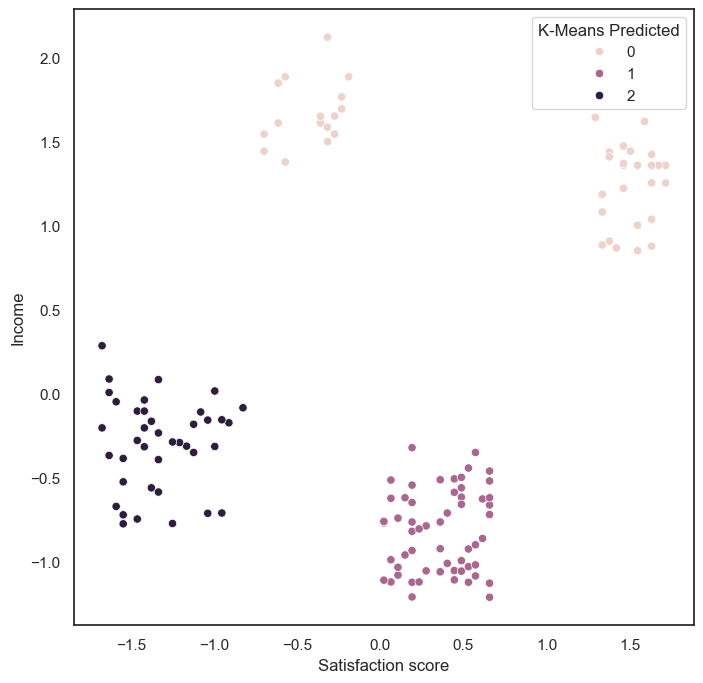

In [114]:
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 8)})

# Create a scatterplot.
sns.set_style('white')

sns.scatterplot(x='Satisfaction score', 
                y ='Income',
                data=X,
                hue='K-Means Predicted',
                           
                )

> If we look more closely at the individual data points, there may be distinct patterns of characteristics or behaviours within the higher-income with low-satisfaction groups and higher-income with higher-satisfaction that justify splitting the cluster into two. This would allow for more targeted retention strategies and interventions for both subgroups.

> Therefore, Cluster 0 could be reconsidered for further segmentation, especially that there is a significant gap in satisfaction scores or income within this group. Thisadditional split might uncover more meaningful insights and better address specific employee needs for each subgroup.

> **Key Insight for Business(3 clusters):**

>The significant split between Cluster 2 and the other clusters suggests that employees with lower income and low satisfaction might be more vulnerable to turnover. Conversely, Cluster 0, with higher satisfaction and higher income, suggests that employees in this group are likely to be more engaged.

>Interestingly, Cluster 1 shows employees who have higher satisfaction but lower incomes, indicating that satisfaction is not just driven by income alone. There could be other factors contributing to satisfaction that should be explored (e.g., work-life balance, career growth, etc.).

### b) `k=4` based on the silhouette method

`n_clusters=4` → Specifies that the data will be grouped into three clusters.

`max_iter=300` → The algorithm runs for a maximum of 300 iterations (stops earlier if convergence is reached).

`init='k-means++' `→ Improves cluster initialization to avoid poor convergence.

`random_state=0` → Ensures results are reproducible.

`.fit(X)` → Trains the K-Means model on X.

Retrieve the assigned cluster labels for each data point using  `kmeans.labels_`.

Add Cluster Labels to the Dataset
 
`hue='K-Means Predicted'` → Colors each data point based on its assigned cluster.
 
`diag_kind='kde'` → Uses Kernel Density Estimation (KDE) for smoother diagonal distributions.

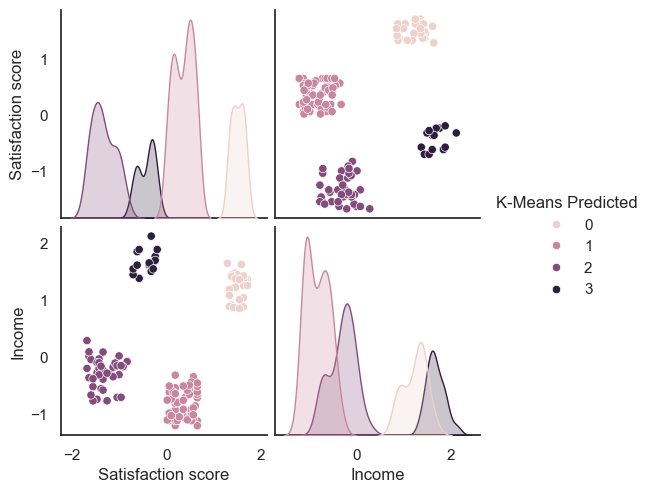

In [118]:
# Use six clusters.
kmeans = KMeans(n_clusters = 4, 
                max_iter = 300,
                init='k-means++',
                random_state=0).fit(X)

clusters = kmeans.labels_

X['K-Means Predicted'] = clusters

# Plot the predicted.
sns.pairplot(X,
             hue='K-Means Predicted',
             diag_kind='kde')

Count the Number of Observations in Each Predicted Cluster.
 
Use `value_counts()` for the number of data points assigned to each cluster.

In [120]:
# Check the number of observations per predicted class.
X['K-Means Predicted'].value_counts()

K-Means Predicted
1    60
2    39
0    25
3    18
Name: count, dtype: int64

The output shows the distribution of observations across the different clusters predicted by the K-Means algorithm:

>It seems that **Cluster 1** has the highest number of observations, while **Cluster 3** has the least. The imbalance between the clusters may suggest some clusters are more dominant or representative of the overall dataset, and the smaller clusters (like Cluster 3) could represent specific niche groups that may require a different approach. In this case employees with high income and yet low satisfaction. 

**Follow the steps:** 

Adjusts the default figure size for all Seaborn plots to 8x8 inches.Ensures the scatterplot is large and clear.

Sets the background style of the plot to `"white"`.Removes grid lines and background shading for a cleaner look.

`x='Satisfaction score'`: Sets the x-axis to Satisfaction Score.

`y='Income'`: Sets the y-axis to Income.

`data=X2`: Uses the dataset X2 for plotting.

`hue='K-Means Predicted'`:  Colors each data point based on its assigned cluster.

<Axes: xlabel='Satisfaction score', ylabel='Income'>

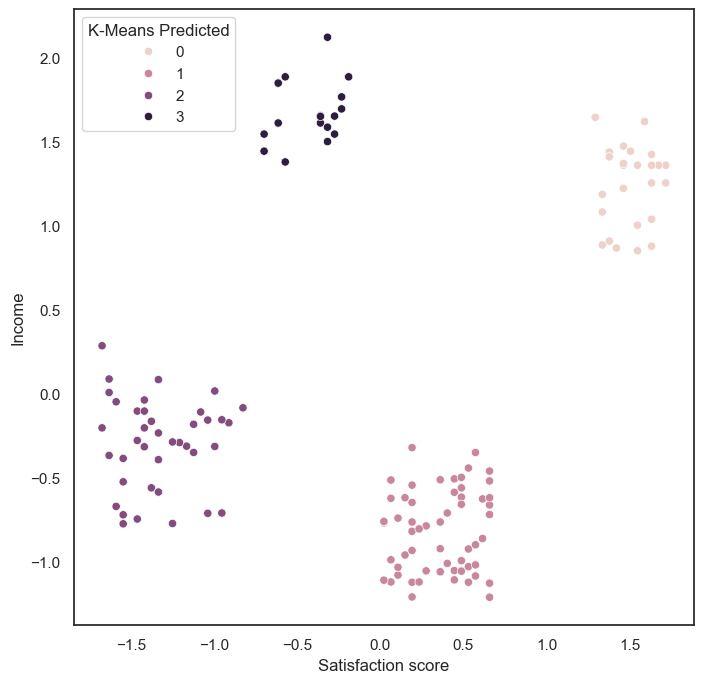

In [124]:
# Set plot size.
sns.set(rc = {'figure.figsize':(8, 8)})

# Create a scatterplot.
sns.set_style('white')

sns.scatterplot(x='Satisfaction score', 
                y ='Income',
                data=X,
                hue='K-Means Predicted',
                           
                )

The scatter plot shows how employees are segmented perfectly in 4.

Optimal clusters **(K) = 4**, chosen based on the silhouette Method.

Employees have been grouped into four distinct clusters based on their Satisfaction Score and Monthly Income.
Each employee now has a Cluster ID, which helps identify different employee groups. These clusters can be analyzed to tailor retention strategies.

**Each cluster is marked with a different color, representing different employee groups:**

**Cluster 0 (Light pink)**: Employees with high satisfaction and high income.

**Cluster 1 (Light purple)**: Employees with moderate satisfaction and low income.

**Cluster 2 (Dark purple)**: Employees with low satisfaction but low to moderate income.

**Cluster 3 (Dark blue)**: Employees with low to moderate satisfaction and high income.

**Key Insight for Business:**

**Cluster 0:** This cluster shows employees with both high satisfaction and high income, likely representing employees who are the most satisfied and engaged. They might be the most loyal to the company.

**Cluster 1:** Employees in this group have moderate satisfaction despite lower income. This indicates that factors other than income (e.g., job satisfaction, work environment) might be contributing to their happiness. 

**Cluster 2:** Employees with low satisfaction and low income might be at high risk of turnover. This group may require immediate attention, such as salary adjustments or career development opportunities.

**Cluster 3:** These employees with low satisfaction but still earn higher wages, which could be a potential concern for retention.This indicates that factors other than income (e.g. work environment) might be contributing to their dissatisfaction.




### Share Findings:

Data wrangling and preprocessing have already been completed in previous steps.

Data normalization using StandardScaler was applied to bring all features to the same scale, ensuring that variables with larger numerical ranges (such as income) don't overpower smaller-range variables (like satisfaction score). This step is crucial for clustering algorithms like K-Means to ensure fair contribution from all variables.

Used `pairplot()` to visualize the correlations between variables, focusing on Income and Satisfaction Score, to identify any patterns. Visually, it was clear that the data could be grouped into four segments. To refine this observation, the Elbow and Silhouette methods were used to determine the optimal number of clusters.

Elbow method suggested `K = 3` clusters.
Silhouette method suggested `K = 4` clusters.

Based on these findings, the KMeans clustering algorithm was applied, with K = 4 identified as the optimal number of clusters, showing minimal overlap between the segments.
  
The K-Means clustering model identified **4 distinct clusters** based on Income and Satisfaction Score.

**Cluster 0:** High satisfaction and high income—likely the most loyal and engaged employees.

**Cluster 1:** Moderate satisfaction but lower income—happiness likely stems from factors beyond income (e.g., work environment).

**Cluster 2:** Low satisfaction and low income—high risk of turnover; requires immediate intervention.

**Cluster 3:** Low satisfaction but higher income—dissatisfaction may be due to factors other than income (e.g., work environment).

**Actionable Insights:**

**Retention(Cluster 0):** Continue to provide recognition and rewards to maintain engagement. These employees are likely to stay, so ensuring job satisfaction and growth is key to keeping them loyal.


**Enhance Satisfaction(Cluster 1):** Focus on improving work conditions, providing growth opportunities, and offering non-financial incentives to increase satisfaction, even if income remains moderate.

**Immediate Action(Cluster 2):** Address income disparities and provide career development opportunities to boost satisfaction and reduce the risk of turnover. Consider salary adjustments and more recognition.

**Work Environment (Cluster 3):** Investigate and improve the work environment to address dissatisfaction. While these employees earn more, factors like workload, management, or work-life balance might be affecting their satisfaction.

The clusters are well-separated, with **higher-income groups generally showing higher satisfaction scores**, while **lower-income groups tend to have lower satisfaction scores**.However, this doesn't necessarily mean that higher income always leads to higher satisfaction.By addressing the specific needs of each cluster, the company can improve retention and overall employee satisfaction.


### **4.3.Tree** 

A decision tree is used for classification and regression tasks. It models decisions and their possible consequences by splitting data into branches based on feature values. This helps make predictions or decisions by following a tree-like structure, where each node represents a decision based on an attribute. **The Decision Tree is chosen for classification because it handles both categorical and numerical data well and offers interpretability.**

**Decision tree is used to classify employees based on whether they are likely to stay or leave the company based on features such as age, income, and satisfaction score.**

> **4.3.1.Importing data and preprocessing has been done in previous steps.**

#### **4.3.2.Split Data** 

**Steps:**

`tree`: For decision tree visualization.

`DecisionTreeClassifier`: The model used for classification.

`export_text`: Convert the decision tree into a readable text format.

`train_test_split`: Split the data into training and testing sets.

`accuracy_score, classification_report, confusion_matrix`: To Evaluate model performance.

`seaborn & matplotlib.pyplot`: Use for visualizing results.

Convert Satisfaction Score into a binary classification target using `if` and `apply(lambda)` method.

`1` = Satisfied (score ≥ 0)

`0 `= Dissatisfied (score < 0)

Assumes scores are standardized, meaning 0 is the median.

**Features (X)**: `Business Travel`, `Education`, `Gender`, `Age`, `Income`, `Working Years`.

**Target (y)**: `Overall Satisfaction` (1 = Satisfied, 0 = Dissatisfied).



In [129]:
# Import tree and export_text.
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier , export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


# Creating the target variable (Overall Satisfaction: Satisfied vs Dissatisfied)
df2["Overall_Satisfaction"] = df2["Satisfaction score"].apply(lambda x: 1 if x >= 0 else 0)  # Since scores are standardized

# Selecting features for prediction
features = ["Business Travel", "Education", "Gender", "Age", "Income", "Working Years"]
X = df2[features]
y = df2['Overall_Satisfaction']

Since the data has been normalised previously(`satisfaction_score > =50` is considered as `Satisfied` and a `satisfaction_score <=49` is considered as Dissatisfied) now `satisfaction score >= 0` considered as` Satisfied` and  `satisfaction score < 0` considerd as `Dissatisfied`. (Converted Satisfaction Score into a binary classification target) 

#### **4.3.3.Specify and fit the model**

**Steps:**


Use `80%` Training Data, `20%` Testing Data.

`random_state=0` ensures consistent results on each run.

Uses `Gini` impurity as the splitting criterion.

Fits the model using training data.


In [132]:
# Splitting data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Building and training the Decision Tree model
model = DecisionTreeClassifier(criterion='gini')
model.fit(X_train, y_train)

DecisionTreeClassifier()

**Step:**


Predict Overall Satisfaction for test data using `y_pred` and `predict(`) method based on `X_test`.


In [135]:
# Making predictions
y_pred = model.predict(X_test)


#### **4.3.4.Visualise the model** 

**a.Visualize the Decision Tree**

Convert the decision tree structure into a readable text-based representation using `.export_text(model)`.

**b.Visualize the Matplotlib Tree**

Plot the decision tree in a graphical format using `plot_tree()`.

`filled=True`: colour the nodes based on classification.

`rounded=True`: give rounded corners for better visualization.


|--- feature_0 <= 0.50
|   |--- feature_3 <= 0.88
|   |   |--- class: 1
|   |--- feature_3 >  0.88
|   |   |--- feature_4 <= 0.34
|   |   |   |--- class: 0
|   |   |--- feature_4 >  0.34
|   |   |   |--- class: 1
|--- feature_0 >  0.50
|   |--- feature_0 <= 1.50
|   |   |--- feature_4 <= -0.92
|   |   |   |--- class: 1
|   |   |--- feature_4 >  -0.92
|   |   |   |--- class: 0
|   |--- feature_0 >  1.50
|   |   |--- feature_3 <= 0.79
|   |   |   |--- feature_3 <= -0.10
|   |   |   |   |--- class: 1
|   |   |   |--- feature_3 >  -0.10
|   |   |   |   |--- class: 0
|   |   |--- feature_3 >  0.79
|   |   |   |--- class: 1



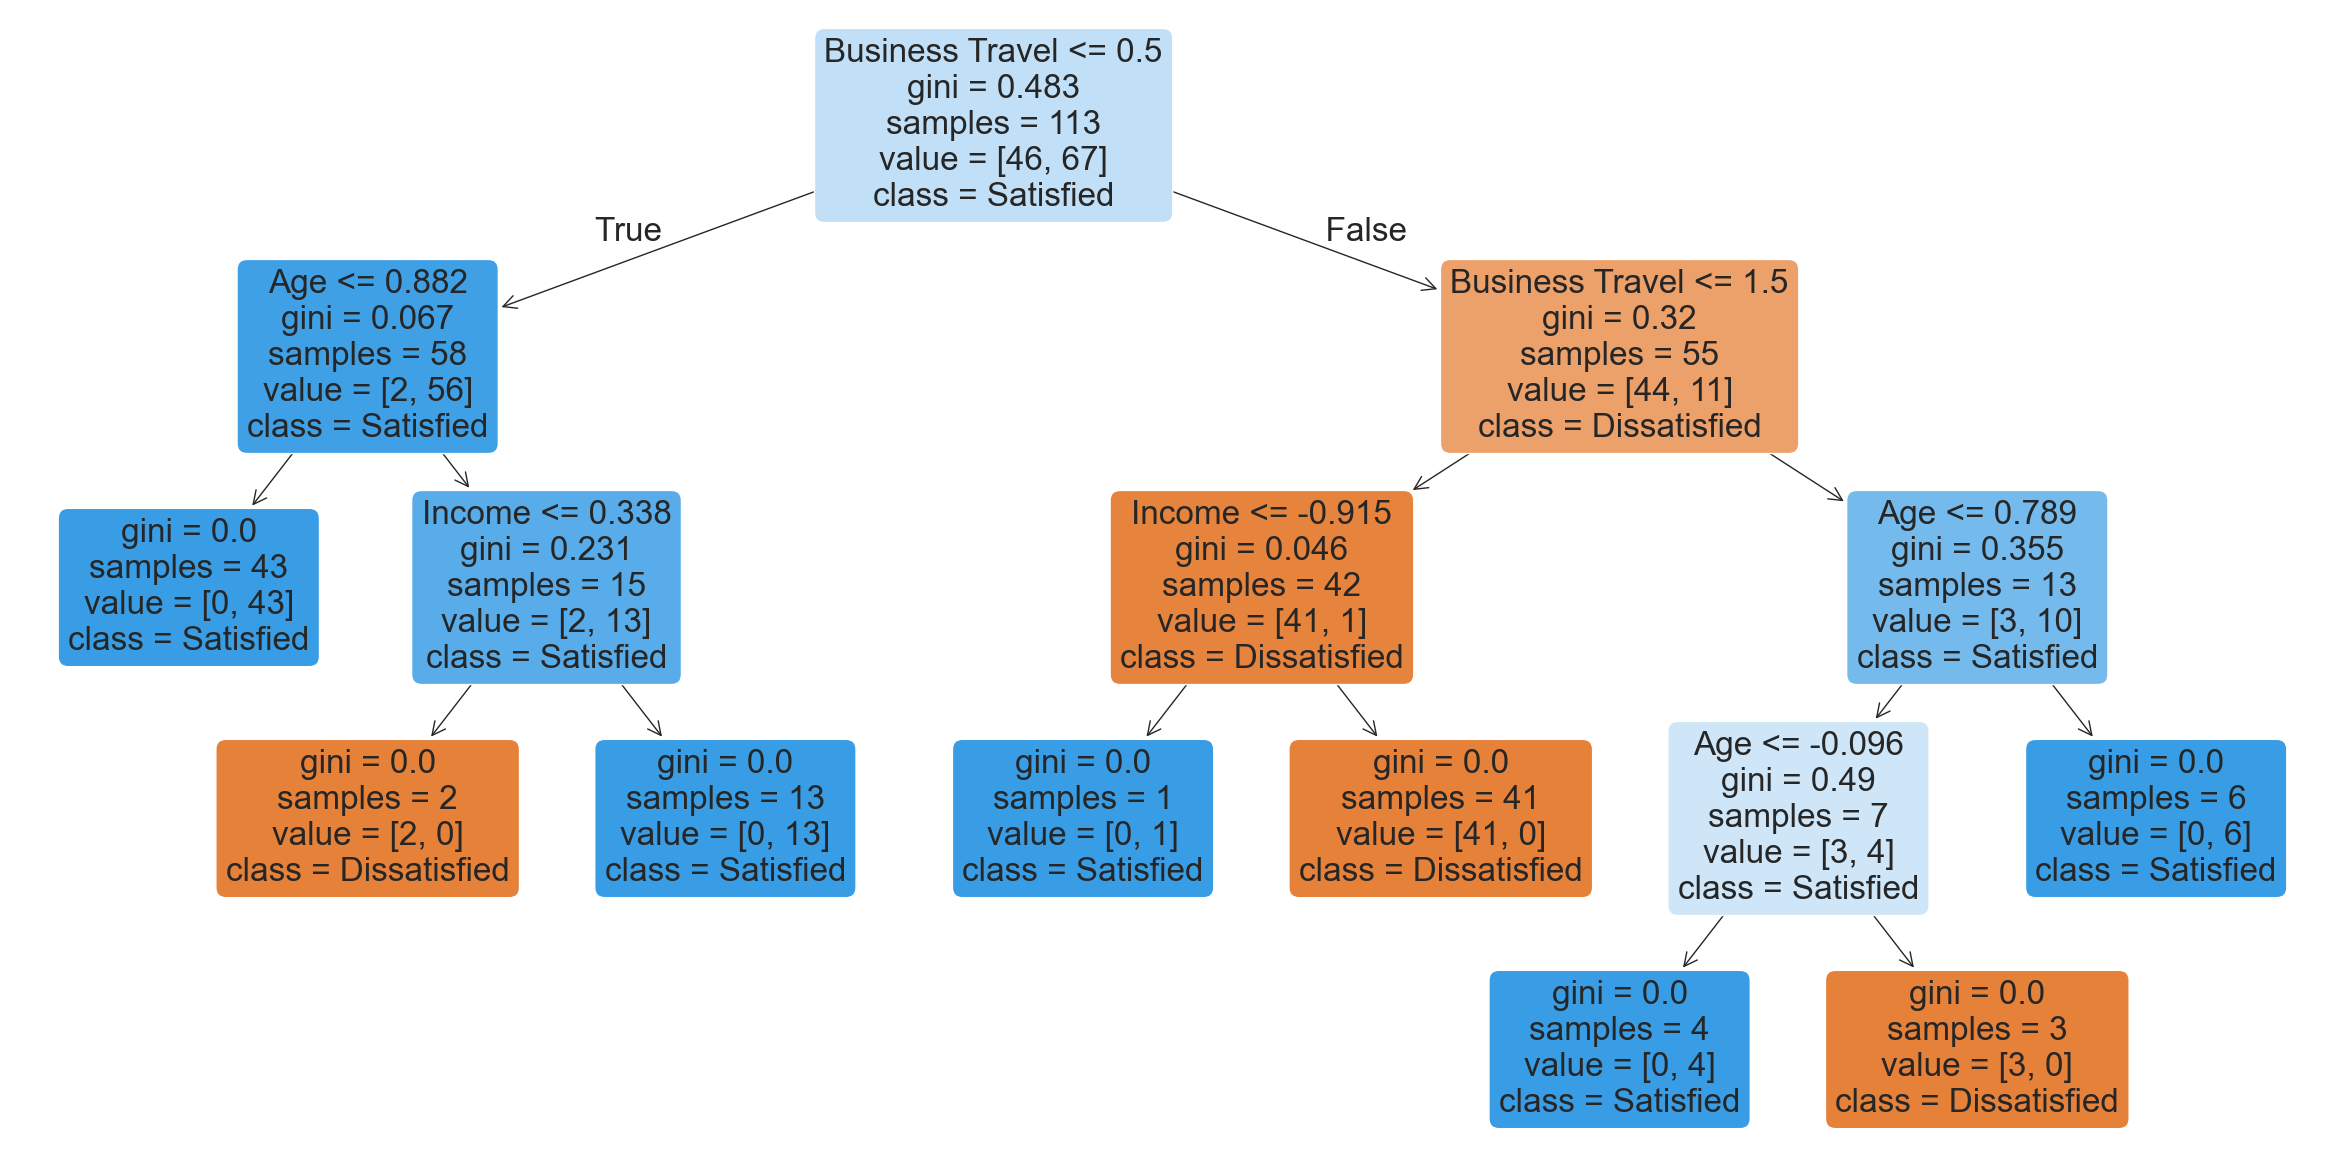

In [138]:
# Create the text tree.
text_representation = tree.export_text(model)

# View the text tree.
print(text_representation)



# Plot the Matplotlib tree.
plt.figure(figsize=(30, 15))

tree.plot_tree(model,
               feature_names=X.columns,
               class_names=['Dissatisfied', 'Satisfied'],
               filled=True,
               rounded=True)

# View the plot.
plt.show()

#### **4.3.5.Evaluate Model Performance**

Accuracy Score: Percentage of correctly classified instances.

**Classification Report:**

`Precision`: How many predicted positives were correct use `accuracy_score(y_test, y_pred)`.

`Recall`: How many actual positives were correctly predicted use `classification_report(y_test, y_pred)`.

`F1-score`: Balances precision and recall.

`Confusion Matrix`: Shows true vs. predicted values use `confusion_matrix(y_test, y_pred`.

 Print the classification report and accuracy score.

 Use a heatmap to display classification performance.Helps identify misclassifications.



Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        18

    accuracy                           1.00        29
   macro avg       1.00      1.00      1.00        29
weighted avg       1.00      1.00      1.00        29

Decision Tree Model Accuracy: 1.00


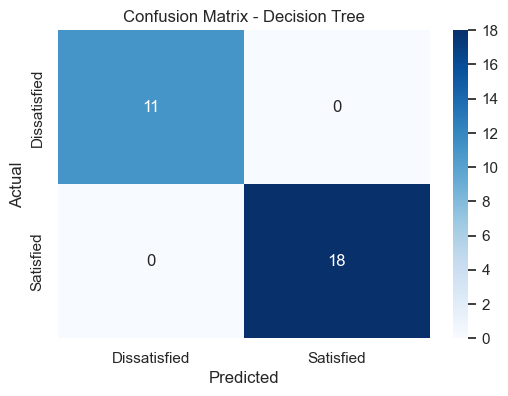

In [141]:
# Evaluating the model
accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display classification report
print("\nClassification Report:\n", classification_rep)

# Display accuracy
print(f"Decision Tree Model Accuracy: {accuracy:.2f}")

# Plot confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Dissatisfied", "Satisfied"], yticklabels=["Dissatisfied", "Satisfied"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")
plt.show()


Precision (How many predicted positives were actually correct?)


Class 0: 1.00  All predictions for "Dissatisfied" were correct.

Class 1: 1.00  All predictions for "Satisfied" were correct.

Recall (How many actual positives were correctly identified?)


Class 0: 1.00  All actual "Dissatisfied" cases were predicted correctly.

Class 1: 1.00  All actual "Satisfied" cases were predicted correctly.

F1-score (Harmonic mean of Precision & Recall)

Class 0: 1.00  Perfect balance between precision and recall.

Class 1: 1.00  No misclassifications.

Support (Number of actual instances in each class)

Class 0 (Dissatisfied): 11 cases in test data.

Class 1 (Satisfied): 18 cases in test data.

Total test samples: 29.





   

## Pruning the tree Model

Pruning reduces the complexity of the decision tree, which can help prevent overfitting.It removes branches that have little to no predictive value, thus reducing overfitting and improving generalization.
We can set `max_depth`, `min_samples_split`, or `min_samples_leaf` to limit the tree's growth.

`max_depth=3`: Limits the tree depth to avoid overfitting.

`class_weight='balanced'`: Adjusts for class imbalance by giving more weight to the minority class.

`random_state=0`: Ensures reproducibility of results.

In [145]:
# Prune the tree.
clf_pruned = DecisionTreeClassifier(criterion='gini', max_depth=3, class_weight='balanced', random_state=0)


# Fit the model.
clf_pruned.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=3, random_state=0)

In [147]:
# Predict on the test set.
y_pred_pruned = clf_pruned.predict(X_test)

# View the output.
y_pred_pruned

array([0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 1, 0, 1], dtype=int64)

In [149]:
# Evaluate the accuracy of the pruned model.
print("Accuracy (Pruned):",
      accuracy_score(y_test, y_pred_pruned))

print("\nConfusion Matrix (Pruned):\n",
      confusion_matrix(y_test, y_pred_pruned))

print("\nClassification Report (Pruned):\n",
      classification_report(y_test, y_pred_pruned))

Accuracy (Pruned): 0.9655172413793104

Confusion Matrix (Pruned):
 [[11  0]
 [ 1 17]]

Classification Report (Pruned):
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.94      0.97        18

    accuracy                           0.97        29
   macro avg       0.96      0.97      0.96        29
weighted avg       0.97      0.97      0.97        29



>The first model uses default settings and may overfit or favor the majority class, while the second model applies depth control and class balancing to prevent overfitting and improve fairness across classes.


**Accuracy**: 97%

**Macro Avg F1-Score**: 0.96

**Weighted Avg F1-Score**: 0.97


Key Takeaways:

The pruned tree is highly accurate and balanced across both classes.

It makes **no false negatives** for **dissatisfied employees** (Recall = 1.00 for Class 0).

It has only **one misclassification** for **satisfied employees**.

The model is well-generalized and **not overfitting**.

This pruned decision tree is ideal for identifying at-risk employees with high confidence, enabling early intervention.

### **Visualise the Pruned tree**

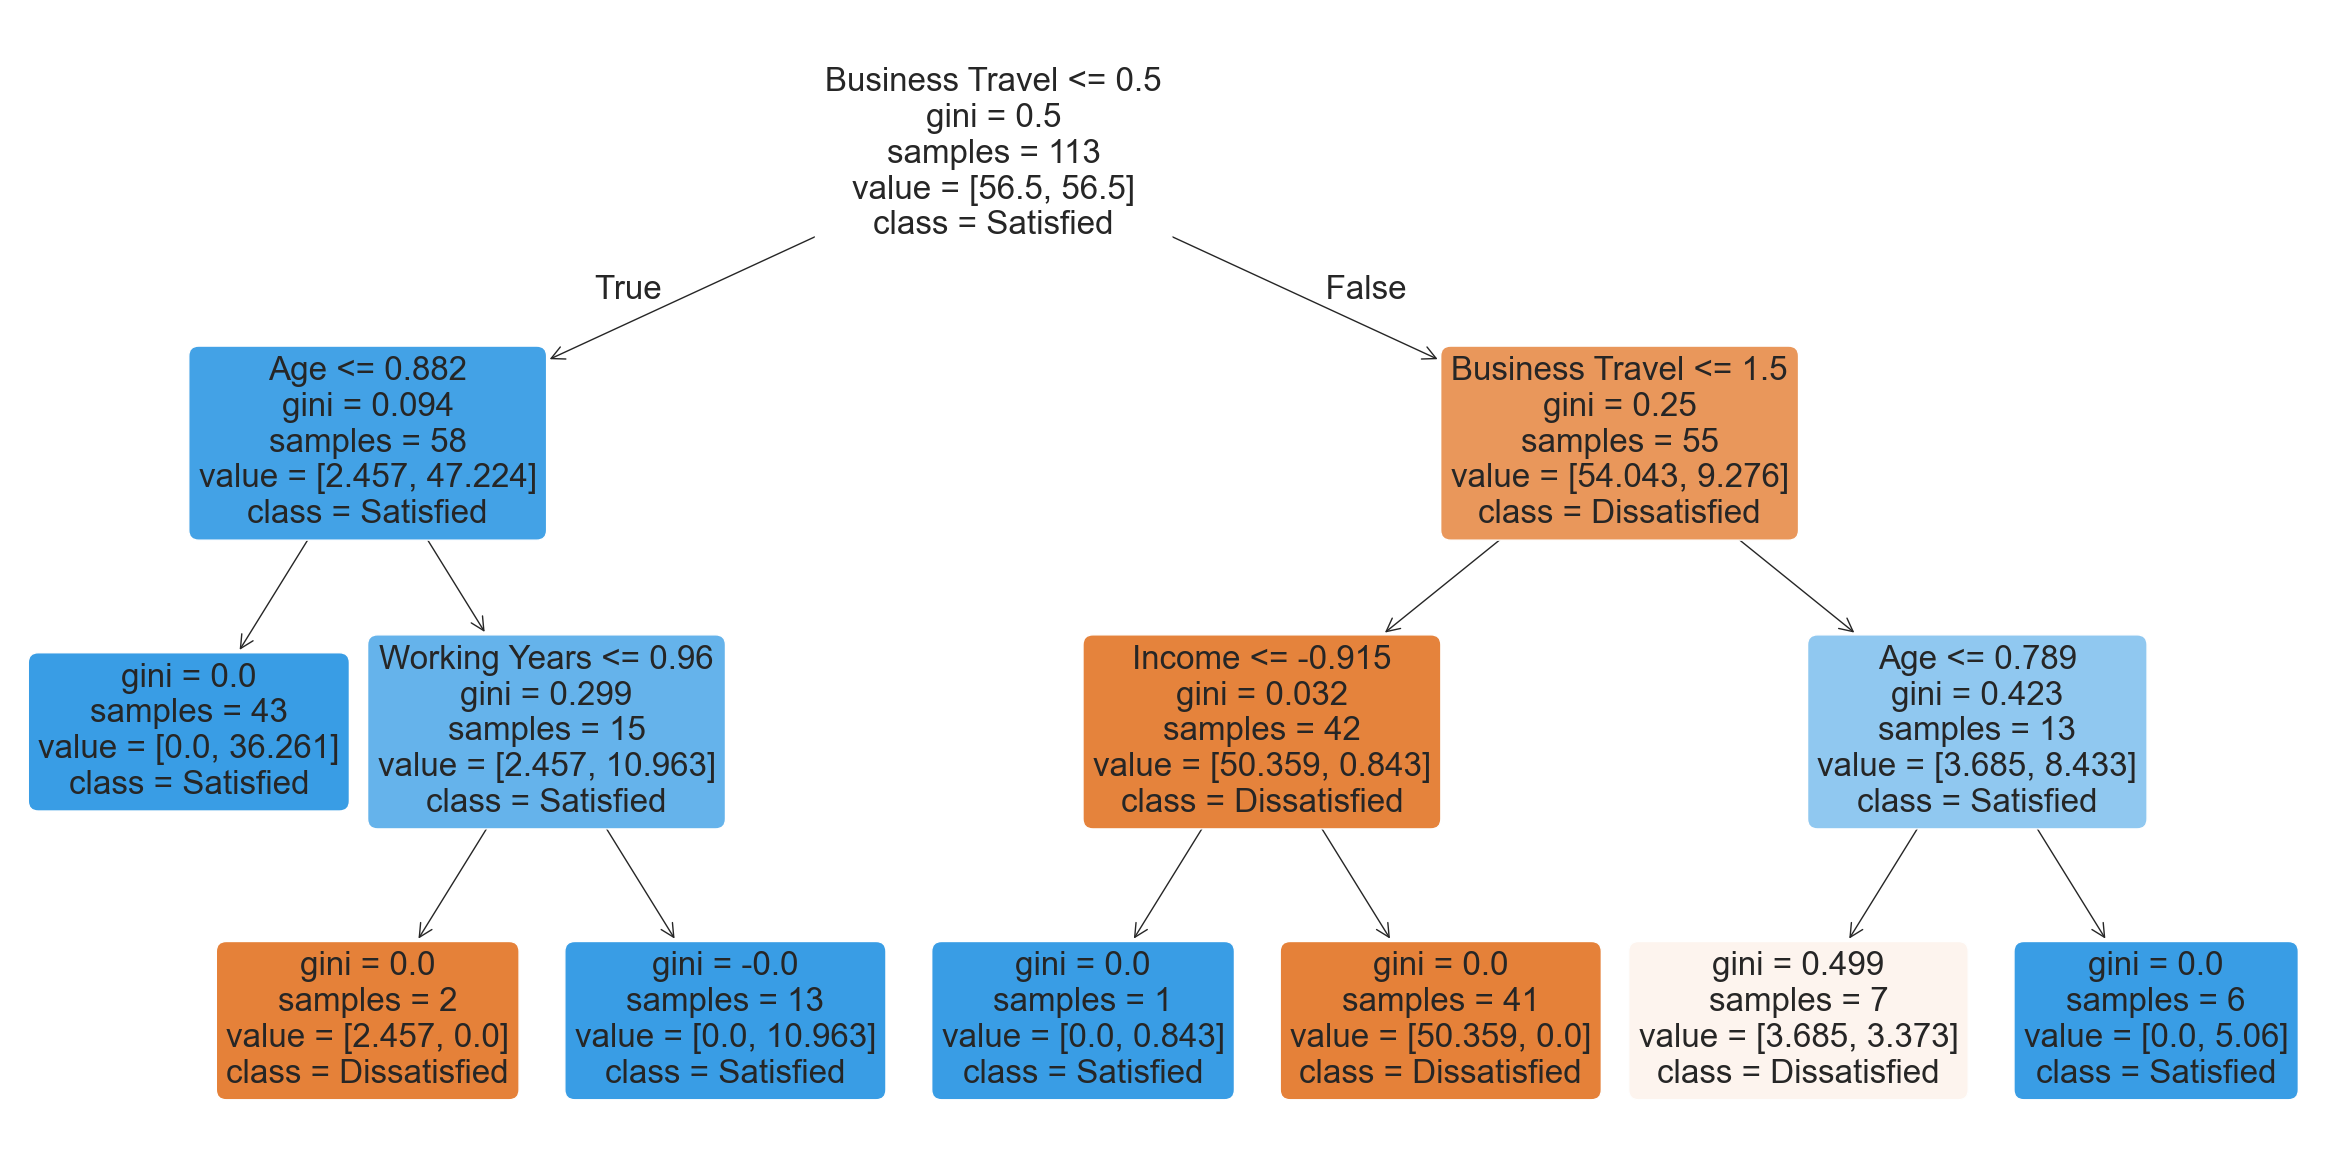

In [152]:
# Plot the Matplotlib tree.
plt.figure(figsize=(30, 15))

tree.plot_tree(clf_pruned,
               feature_names=X.columns,
               class_names=['Dissatisfied', 'Satisfied'],
               filled=True,
               rounded=True)

# View the plot.
plt.show()

**Primary Split – Business Travel:**

The most influential feature for predicting satisfaction is Business Travel.

Employees who travel less frequently are generally more satisfied.

**Age Matters:**

Among less-traveling employees, younger employees (Age ≤ 0.882, scaled) show higher satisfaction.

Within this group, 43 employees are strongly predicted to be satisfied.

**Working Years Effect:**

When age is higher but Working Years ≤ 0.96, employees still tend to be satisfied.

More years of work might contribute to dissatisfaction if other factors aren’t favorable.

**Income Impact:**

For frequent travelers, lower income (≤ -0.915) strongly indicates dissatisfaction.

High dissatisfaction is found in this group — 41 employees predicted dissatisfied.

**Edge Cases:**

A small number of employees defy the patterns (e.g., older high travelers but still satisfied).

These might represent unique roles or exceptional conditions.

### Share Findings:
Data wrangling and preprocessing have already been completed in previous steps.

Data normalization using StandardScaler was applied to bring all features to the same scale, ensuring that variables with larger numerical ranges (such as income) don't overpower smaller-range variables (like satisfaction score).

The data was split as follows:

- **Features (X)**: `Business Travel`, `Education`, `Gender`, `Age`, `Income`, `Working Years`
- **Target (y)**: `Overall Satisfaction` (1 = Satisfied, 0 = Dissatisfied)

The dataset was split into an **80:20 train-test ratio**. Since the data had been normalized previously, **satisfaction scores ≥ 0** were classified as **Satisfied** and **satisfaction scores < 0** were classified as **Dissatisfied** (converting the satisfaction score into a binary classification target).

Next, the data was visualized using **Matplotlib** for better insight, and the model's performance was evaluated using a **confusion matrix**.


**Key Findings:**

**According to the decision tree, `Age` and `Work Travel` appear to have the greatest influence on the overall score, as the model uses them as key splitting criteria in the decision-making process.** 

For Example :

Bracnh : `Business Travel <= 0.5` , `Age <= 0.88` , `Income <= 0.338` ---> Satisified.

Branch : `Business Travel <= 1.5` , `Income <= -0.91` ---> Disatisfied

The model achieved `100%` accuracy, meaning it perfectly classified employees as Satisfied (score ≥ 50) vs. Dissatisfied (score < 50) in the test set.

The classification report shows perfect precision, recall, and F1-score for both classes.

The confusion matrix confirms that no misclassifications occurred.

However, this might indicate **overfitting** since the dataset is relatively small and everything is perfectly `100%` . To improve generalization, we can:

 - Apply pruning to the tree.

 - Use cross-validation for better performance assessment.

After Prunning and Balancing weight of the samples:

**Business Travel is the top predictor — less travel links to higher satisfaction.**

**Younger employees and those with fewer working years are more likely to be satisfied**.

**Low income + frequent travel = high dissatisfaction**.
   
The model is well-generalized and **not overfitting**.

This pruned decision tree with `97%` accuracy is ideal for identifying at-risk employees with high confidence, enabling early intervention.

**Comparison of Pruned vs. Unpruned Decision Tree Accuracy:**

**Unpruned Decision Tree (Accuracy = 1.0):**

The unpruned decision tree model achieves perfect accuracy, but this could indicate overfitting. It might have memorized the training data, leading to excellent performance on training data but poor generalization to unseen data. A model that overfits fails to make reliable predictions when it encounters new, unseen data, thus reducing its ability to perform well in real-world scenarios.

**Pruned Decision Tree (Accuracy = 0.97):**

The pruned model has slightly reduced accuracy, but it is generally a more robust model. Pruning helps by removing unnecessary complexity (i.e., branches that capture noise or rare patterns in the data). The decision tree is constrained to a maximum depth of 3, which forces it to focus on the most important features. This can help improve generalization and reduce overfitting.

**Justification for Pruning Choices :**

**max_depth=3:**

Limiting the depth of the tree helps prevent it from learning overly specific patterns from the data that may not generalize well. A smaller tree is easier to interpret, and it is more likely to make predictions based on the most important features rather than noise or outliers.

**class_weight='balanced':**

When there is an imbalance in class distribution (e.g., many employees in one category and fewer in another), the model may be biased towards predicting the majority class. Using class_weight='balanced' adjusts the weights inversely proportional to class frequencies, which ensures that the model gives appropriate importance to both classes, improving its ability to predict minority class labels accurately.

## Sentiment Analysis

Sentiment Analysis is a technique used to determine the emotional tone or sentiment behind a piece of text, typically classifying it into categories such as positive, negative, or neutral. In the context of employee feedback, sentiment analysis can bring several key benefits:

**Identify Employee Satisfaction & Dissatisfaction:**
By analyzing employee reviews, you can gain valuable insights into overall sentiment. Positive sentiment indicates content employees, while negative sentiment points to areas of dissatisfaction. This helps you target issues affecting morale and retention.

**Monitor Changes Over Time:**
With periodic surveys and feedback, sentiment analysis can track changes in employee sentiment, helping to assess the effectiveness of organizational changes or interventions designed to improve satisfaction.

**Improve Employee Retention:**
By understanding employee emotions, especially negative sentiment, companies can address underlying issues (e.g., management, work-life balance) that may lead to high turnover, helping to improve retention rates.

**Focus on Areas Needing Improvement:**
Negative feedback identified through sentiment analysis can highlight specific areas in need of improvement, such as communication gaps or ineffective management practices. Targeting these areas can enhance employee experience.

**Boost Productivity:**
Employees who feel heard and satisfied are generally more productive. By addressing negative sentiment and improving satisfaction, you create a more positive and productive workplace environment.

**Support Decision-Making:**
Sentiment analysis provides data-driven insights that can inform decisions regarding workplace policies, employee engagement initiatives, and management strategies.

In short, sentiment analysis allows organizations to quantify employee feelings, identify problem areas, and make informed decisions to improve satisfaction, retention, and productivity.

### **1.Import Data and Prepare Data**

### **a.Import the data and necessary Libraries**
 
 • Import the `Pandas` and `NumPy` libraries.

 • Create new variables `df3` to store the data set.

 • Import the data set with Pandas and create a DataFrame.


In [159]:
# Import the necessary libraries, packages, and modules.
import pandas as pd
import numpy as np

# Import the employee survey dataset and call them employee_data and metadata
df3 = pd.read_csv("employee_satisfaction_data.csv")



### **b.Explore the data** 
 Perform exploratory data analysis (EDA).
 
 The `info(`), `head()` methods are essential for Exploratory Data Analysis (EDA) because they provide a quick overview of the   dataset:

**info()** – Displays the structure of the dataset, including column names, data types, and missing values.

**head()** – Shows the first few rows, giving a quick preview of the dataset’s contents.

These methods help in understanding data quality, detecting anomalies, and guiding further cleaning and analysis.

In [162]:
# Perform EDA on the DataFrame.
print(df3.head())
print(df3.info())


   Rowid    Business Travel         Education  Gender  Age  MonthlyIncome (K)  \
0      1  Travel_Frequently  Higher Certicate  Female   50               6.60   
1     96         Non-Travel           A Level  Female   32               1.57   
2      2         Non-Travel           A Level    Male   19               2.40   
3     53         Non-Travel           A Level  Female   20               2.07   
4     97      Travel_Rarely           Masters  Female   55              15.97   

   Total Working Years  satisfaction_score  \
0                   22                  32   
1                    0                  64   
2                    1                  68   
3                    1                  61   
4                   27                 100   

                                              Review  
0  Stuck with low wages for years, management doe...  
1  ServiceFirst is a great start for my career, l...  
2                  I'm learning a ton here, love it!  
3  ServiceFirst 

### **c.Prepare the Data**

**following steps:**

We're only interested in the Review column. hence, we’ll drop the unnecessary columns.

Specify the DataFrame as df, and add the drop() method.

Inside the brackets, specify:

The `columns=[]` parameter. Add the names of the columns to be dropped (e.g. Age, Education, and Gender ..].

Add the parameter `axis=1`.

Add the parameter `inplace=True`.

View the DataFrame with the `shape` and `head()` methods.


In [165]:
#Drop Unnecessary columns
df3.drop(columns = ['Rowid','Business Travel','Education','Gender','Age','MonthlyIncome (K)','Total Working Years','satisfaction_score'], 
       axis=1, inplace = True)



In [167]:
# View the DataFrame.
print(df3.shape)
df3.head()

(142, 1)


,Review
0,"Stuck with low wages for years, management doe..."
1,"ServiceFirst is a great start for my career, l..."
2,"I'm learning a ton here, love it!"
3,"ServiceFirst is a great start for my career, l..."
4,"I've been with ServiceFirst for over a decade,..."


> There is now only one column (`Review`).

### Determine and remove missing values

Use the `isnul().sum()` method to determine if there are missing values. Remember to specify the DataFrame as `df`.

In [171]:
# Missing values in data
df3.isnull().sum()

Review    2
dtype: int64

> There are 2 missing values. Remove the values and determine whether all the missing values were indeed removed.

The steps are:
- Create a new variable (e.g. `df3`) to store the new DataFrame.
- Specify the original DataFrame as `df3`, and add the `dropna()` method.
- View the new DataFrame with the `shape` method.

In [174]:
# Remove missing values from DataFrame?
df4 = df3.dropna()

# View DataFrame.
df4.shape

(140, 1)

> The DataFrame has 140 rows and one column. A total of 2 rows were dropped, which corresponds with the number of missing values.

Let's confirm that we don't have any missing values. Specify the DataFrame as `df4`, and use the `isnul().sum()` method.

In [177]:
# Missing values in data?
df4.isnull().sum()

Review    0
dtype: int64

> There are no missing values. We can now proceed to the pre-processing of the textual data.

# 2. Pre-process the data
The primary goal of text data preprocessing is to standardize customer feedback into a consistent format, making it easier to analyze and compare. For instance, comparing two sentences—one in lowercase and the other in uppercase—could yield different sentiment or polarity results. For this dataset, the following preprocessing steps will be performed:


-  all text to lowercase

-  Remove punctuation

-  Eliminate duplicate values/rows

-  Save the cleaned data as a CSV file

## a) Change all the words in the `Review` to lower case
The DataFrame only contains one column (e.g. `Review`). Although you don’t have to specify the column name in this instance, we’ll specify the column in this exercise for future reference. When you have more than one column in the data set, you’ll need to specify the column name. 

Follow these prompts to write the code:
- Specify the column and DataFrame as `df4.['Review']`.
- Add the `apply()` method to apply a function along an index (`axis=0`) or column (`axis=1`). The default is `axis=0`.
  
  - Inside the brackets, use a Lambda function to iterate over each index/row (e.g. `x`).
  - Specify the `lower()`, `split()`, and `join()` built-in string methods. The `split()` method will split the string into separate segments. Thereafter, each segment will be converted to lowercase with the `lower()` method. After each segment has been transformed, the `join()` method will combine all the segments into a string and replace the original string. The new string will be all lowercase.
- View the DataFrame with the `head()` method.

In [181]:
# Transform data to lower case.
df4['Review'] = df4['Review'].apply(lambda x: " ".join(x.lower() for x in x.split()))

# Preview the result.
df4['Review'].head()

0    stuck with low wages for years, management doe...
1    servicefirst is a great start for my career, l...
2                    i'm learning a ton here, love it!
3    servicefirst is a great start for my career, l...
4    i've been with servicefirst for over a decade,...
Name: Review, dtype: object

> The Reviews are now all in lower case.

## b) Remove punctuation              
Punctuation plays a significant role in conveying emotions in human communication. For instance, if you're excited or frustrated, you might end a sentence on Twitter with several exclamation marks. To standardize the data and make comparisons between comments easier, we will remove all punctuation.

Follow these prompts to write the code:
- Specify the column and DataFrame as `df4.['Review']`.
- Add the string replace method (`str.replace()`).
- Inside the brackets, specify the parameters to be replaced. As we want to remove all the punctuation, we can use `'[^\w\s]'`, which indicates to Python that all the punctuation should be identified and replaced with white space (e.g. `''`).
- `regex=True` This tells pandas that the pattern is a regular expression.
- View the DataFrame with the `head()` method.

In [185]:
# Remove punctuation using regex
df4['Review'] = df4['Review'].str.replace('[^\w\s]', '', regex=True)

# Preview the result
df4['Review'].head()


0    stuck with low wages for years management does...
1    servicefirst is a great start for my career le...
2                       im learning a ton here love it
3    servicefirst is a great start for my career le...
4    ive been with servicefirst for over a decade a...
Name: Review, dtype: object

> Concentrate on index `3` and compare the raw data with the outputs after removing the capitalisation and punctuation:
>- raw data:             **`I'm learning a ton here, love it!`**
>- change to lowercase:  **`i'm learning a ton here, love it!`**
>- remove punctuation:   **`im learning a ton here love it`**


## c) Drop duplicates from the `Review` column
Some respondents might submit answers twice or even more times. Therefore, it is important to determine whether there are duplicate values. In this exercise, we’ll determine whether we have duplicate values and then more of these duplicate values. Follow these prompts to write the code:
- Specify the DataFrame (e.g. `df4`) and column (e.g. `Review`).
- Add the `duplicated()` and `sum()` methods. This method works similarly to determine missing values with the `isnull().sum()` method we used earlier in the unit. Therefore, Python will return the total number of duplicated rows.

In [189]:
# Check the number of duplicate values in the Comments column.
df4.Review.duplicated().sum()

10

There are a total of 10 duplicated rows. To drop the duplicated rows, follow these prompts:
- Create a new variable (e.g. `Sentiment`) to store a subset of the DataFrame. The subset will contain one copy of each row and, therefore, no duplicated rows.
- Specify the DataFrame (e.g. `df4`).
- Add the `drop_duplicates()` method.
- Specify the column to be subsetted (e.g. `Review`) with `subset=['Review']`. 
- Use the `reset_index(inplace=True)` method to renumber the index so that no empty numbers in the index are visible.
- Preview the data with the `shape` and `head()` methods.

In [192]:
# Drop duplicates.
sentiment = df4.drop_duplicates(subset=['Review'])

# Reset the index.
sentiment.reset_index(inplace=True)

# Preview the data.
print(sentiment.shape)
sentiment.head()

(130, 2)


,index,Review
0,0,stuck with low wages for years management does...
1,1,servicefirst is a great start for my career le...
2,2,im learning a ton here love it
3,4,ive been with servicefirst for over a decade a...
4,5,i feel like i never see my kids because im alw...


Check whether all the duplicated rows were deleted.

In [195]:
# Check the number of duplicate values in the Comments column.
sentiment.Review.duplicated().sum()

0

The duplicated entries in the `Review` column have been removed from the DataFrame. 

## d) Save the output as a CSV file
Save the new DataFrame as a CSV file for the reflection section. The steps are:
- Specify the DataFrame as `sentiment`.
- Add the `to_csv()` method.
- Specify the name of the CSV file (e.g. `sentiment.csv`).
- Check whether the file was saved correctly by importing it with the `pd.read_csv()` method. Remember to save it as a new DataFrame, and view the DataFrame with the `head()` method.

In [199]:
# Save the output as a CSV file.
sentiment.to_csv('safety.csv')

# Import the DataFrame to sense-check.
sentiment2 = pd.read_csv('safety.csv')

# View the DataFrame.
sentiment2.head()

,Unnamed: 0,index,Review
0,0,0,stuck with low wages for years management does...
1,1,1,servicefirst is a great start for my career le...
2,2,2,im learning a ton here love it
3,3,4,ive been with servicefirst for over a decade a...
4,4,5,i feel like i never see my kids because im alw...


# 3. Visualise the most frequently used words

To create a Word Cloud, you’ll first need to string all the comments together into a single variable. Follow these prompts to write the code:
- Create a new variable (e.g. `all_reviews`), and assign it to an empty string as `''`.  
- Create a `for` loop to iterate/cycle over all the comments in the `Reviews` column. 
- Define `i` as the iterator, and specify the range with the `range()` method. Inside the brackets, specify the DataFrame and the index as `0` (e.g. `range(sentiment.shape[0])`).
- Add the contents of each item under `Reviews` to the `all_reviews` string with the `+` operator.
- Add `[i]` to specify the row number under the `sentiment['Review']` for each iteration.

In [202]:
# String all the comments together in a single variable.
# Create an empty string variable.
all_reviews = ''
for i in range(sentiment.shape[0]):
    # Add each reviews.
    all_reviews = all_reviews + sentiment['Review'][i]

Next, we’ll create a word cloud. Follow these prompts to write the code:
- Import the necessary libraries for visualisation (e.g. Matplotlib and Seaborn). Also, import `WordCloud` from `wordcloud`.  
- Set the Seaborn colour palette with the `sns.set(`) method. Specify the `color_codes=True` parameter.
- Create a new variable, (e.g. `word_cloud`) to store the `WordCloud()` method. Specify the following parameters:
  - `width=900`
  - `height=900`
  - `background_color='white'`
  - `colormap='plasma'`
  - `stopwords='none'` (**Hint:** Set the list of words that need to be eliminated (e.g. trivial words like 'this', 'that', 'is', 'was', and 'the'). If this parameter is set to none, the function will consider a built-in list of stopwords to be eliminated. However, you can add words or specify specific words to be ignored.)
  - `min_font_size=10`.
- Add the `generate()` method, and specify the `all_reviews` variable.
- Specify the `figsize=(8, 8)` and `facecolor=None` parameters of the Matplotlib `figure()` function.
- Specify the following Matplotlib functions:
  - `imshow(word_cloud)`
  - `axis('off')`
  - `tight_layout(pad=0)`
  - `show()`.
- Save the word cloud as a PNG file. For example, `plt.savefig('wordcloud_1.png')`.  

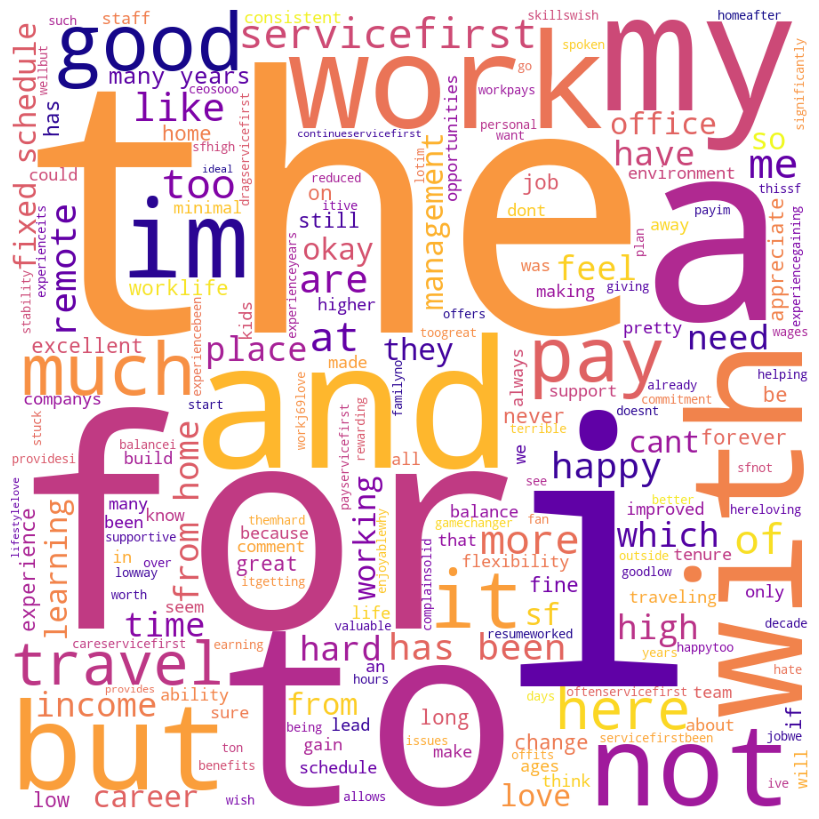

<Figure size 800x800 with 0 Axes>

In [205]:
# Import along with matplotlib and seaborn for visualisation.
from wordcloud import WordCloud 
import matplotlib.pyplot as plt 
import seaborn as sns

# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud object.
word_cloud = WordCloud(width = 900,
                       height = 900,
                       background_color ='white',
                       colormap = 'plasma', 
                       stopwords = 'none',
                       min_font_size = 10).generate(all_reviews) 

# Plot the WordCloud image.                    
plt.figure(figsize = (8, 8),
           facecolor = None) 

plt.imshow(word_cloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

plt.savefig('wordcloud_1.png')
# Note that your word cloud might differ slightly from the one provided.

>The most prominent words based on font size are stopword such i , for , to , the.


Comment out `stopwords='none'` parameter using a hastag (`#`) in front of a line of code, to check which meaningful words are prominent.

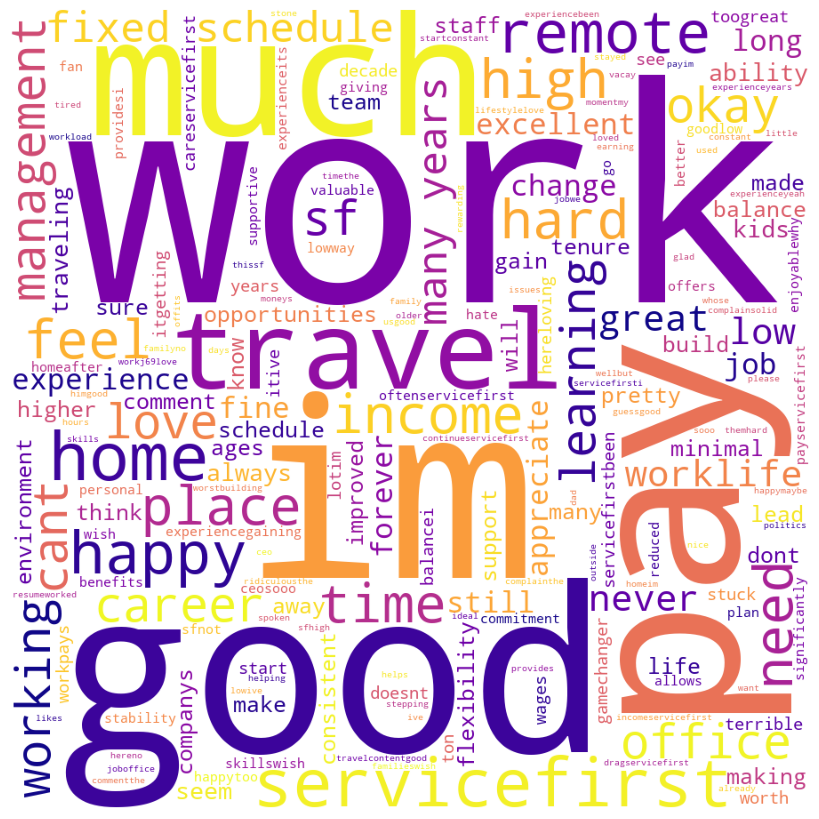

<Figure size 800x800 with 0 Axes>

In [208]:
# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud object.
word_cloud = WordCloud(width = 900,
                       height = 900,
                       background_color ='white',
                       colormap = 'plasma', 
                       # stopwords = 'none',
                       min_font_size = 10).generate(all_reviews) 

# Plot the WordCloud image.                    
plt.figure(figsize = (8, 8),
           facecolor = None) 

plt.imshow(word_cloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

plt.savefig('wordcloud_2.png')
# Note that your word cloud might differ slightly from the one provided.

>The most prominent words are now `work` and `pay` and `good`, compared to previous one `I` , `the` and `for` which make more sense for the analysis.

# 4. Find the most frequently used words with tokenisation
To find the most commonly used words, we will:

- tokenisation
- eliminate stopwords
- visualise the relevant tokens.

## a) Tokenisation

Tokenizing is used to break down text into smaller units, like words or phrases, making it easier to analyze and process text for tasks like sentiment analysis, topic modeling, and text classification.

- Import `nltk` library and from there `word_tokenize` .
- Use the `apply()` method on the `Review` column, and specify the word 'tokenize' (`word_tokenize`) in the method parameters. 
- Assign the output to a new column as `sentiment['tokens']`.
- View the `sentiment` DataFrame with the `shape` method.
- View the tokens column with the `head()` method.

In [211]:
# Import nltk for tokenisation 
import nltk

from nltk.tokenize import word_tokenize

# Tokenise the words.
sentiment['tokens'] = sentiment['Review'].apply(word_tokenize)

# Preview data.
print(sentiment.shape)
sentiment['tokens'].head()

(130, 3)


0    [stuck, with, low, wages, for, years, manageme...
1    [servicefirst, is, a, great, start, for, my, c...
2               [im, learning, a, ton, here, love, it]
3    [ive, been, with, servicefirst, for, over, a, ...
4    [i, feel, like, i, never, see, my, kids, becau...
Name: tokens, dtype: object

> The sentiment DataFrame now consists of three columns (`index`, `tokens` and `Review`). The `tokens` column comprises `tokens`, which are a sequence of characters and individual words derived as a result of splitting the `Review` in the data. In essence, the tokens represent the individual words of each Review in the survey, saved within a single row. 

 Concentrate again on index `3` and compare the raw data and the changes has been done to it:
- raw data:             **`I'm learning a ton here, love it!`**
- change to lowercase:  **`i'm learning a ton here, love it!`**
- remove punctuation:   **`im learning a ton here love it`**
- create tokens: **`[im, learning, a, ton, here, love, it]`**.

The next step is to merge all tokens into one unified list of words. After that, we will calculate the frequency of each word and identify the most frequent tokens in the Review. Here's the code to do that:

- Create a new variable (e.g. `all_tokens`) to store an empty list (e.g. `all_tokens=[]`).
- Create a `for` loop to iterate/cycle over all the tokens in the `tokens` column. 
- Define `i` as the iterator, and specify the range with the `range()` method. Inside the brackets, specify the DataFrame and the index as `0` (e.g. `range(safety.shape[0])`). 
- Add the content of each item under `tokens` to the `all_tokens` list with the `+` operator.
- Add `[i]` to specify the row number under the `sentiment['tokens']` for each iteration.

In [213]:
# Define an empty list of tokens.
all_tokens = []

for i in range(sentiment.shape[0]):
    # Add each token to the list.
    all_tokens = all_tokens + sentiment['tokens'][i]

Next, we’ll determine the frequency distribution of the tokens. Follow these prompts to write the code:
- Import the `FreqDist` class (frequent distribution) from the `nltk.probability` package.
- Create a new variable (e.g. `fdist`) to store the `FreqDist()` class, and specify the `all_tokens` variable as the target of the parameter.
- Preview the data by calling the `fdist` variable.

In [216]:
# Import the FreqDist class.
from nltk.probability import FreqDist

# Calculate the frequency distribution.
fdist = FreqDist(all_tokens)

# Preview data.
fdist

FreqDist({'the': 42, 'for': 27, 'to': 25, 'a': 24, 'i': 23, 'is': 22, 'my': 22, 'and': 22, 'work': 21, 'its': 19, ...})

>From the output, we observe that `the` token appears occurs 42 times, and `for` appears 27 times. Interestingly, `work` only appears 21 times. It's worth noting that the first eight words/tokens, such as(`the`, `for`, `to`, `a`, `i`, `is`,  `my`, `and`), don't carry much significance regarding sentiment analysis.


To address this, we can remove these stopwords. But first, we need to filter out punctuation marks. This means we will eliminate tokens that are neither alphabetic letters nor numbers. We'll accomplish this using a list comprehension across all the tokens. Here’s the code to do that:
- Create a new variable (e.g. `tokens1`) to store the list comprehension. 
- Specify `word` as the iterator, and the comprehension with a conditional `if` statement. The statement will check whether the `token` is a letter or a number by applying the `isalnum()` method to a `word`. Therefore, if the `isalnum` returns `True`, the current value of the `word` will be assigned as an item in a new list (e.g. `tokens1`).
- View the data by specifying the variable `tokens1`.

In [218]:
# Filter out tokens that are neither alphabets nor numbers (to eliminate punctuation marks, etc.).
tokens1 = [word for word in all_tokens if word.isalnum()]

# View the output.
tokens1

['stuck',
 'with',
 'low',
 'wages',
 'for',
 'years',
 'management',
 'doesnt',
 'seem',
 'to',
 'care',
 'servicefirst',
 'is',
 'a',
 'great',
 'start',
 'for',
 'my',
 'career',
 'learning',
 'a',
 'lot',
 'im',
 'learning',
 'a',
 'ton',
 'here',
 'love',
 'it',
 'ive',
 'been',
 'with',
 'servicefirst',
 'for',
 'over',
 'a',
 'decade',
 'and',
 'the',
 'ability',
 'to',
 'work',
 'from',
 'home',
 'has',
 'been',
 'a',
 'gamechanger',
 'for',
 'my',
 'worklife',
 'balance',
 'i',
 'feel',
 'like',
 'i',
 'never',
 'see',
 'my',
 'kids',
 'because',
 'im',
 'always',
 'traveling',
 'for',
 'work',
 'pays',
 'not',
 'high',
 'but',
 'the',
 'experience',
 'is',
 'worth',
 'it',
 'getting',
 'good',
 'experience',
 'here',
 'loving',
 'the',
 'learning',
 'opportunities',
 'at',
 'servicefirst',
 'been',
 'here',
 'forever',
 'but',
 'the',
 'pay',
 'is',
 'still',
 'terrible',
 'too',
 'much',
 'travel',
 'too',
 'great',
 'place',
 'to',
 'gain',
 'experience',
 'gaining',
 'valu

> The output displays a list of tokens.

## b) Eliminate stopwords
We previously noted that stopwords, like conjunctions and prepositions (e.g., ‘as’, ‘the’, ‘to’, ‘and’), have high frequency but don’t contribute to sentiment. These words add noise to the word cloud and can obscure more relevant terms important for the road safety survey.

Remove these stopwords to focus on the frequency distribution of meaningful words. Here’s how we can proceed with the code:

-Import the `stopwords` corpus from the `nltk` package with `from nltk.corpus import stopword`s.
- Create a new variable (e.g. `english_stopwords`) to store the `set()` method with the `stopwords.words('english')` parameter. The survey was conducted in English; therefore, we’ll use the english stopwords parameter. (**Hint:** There are various parameters available for different languages.)
- Create a second variable for the tokens (e.g. `tokens2`) to store the filtered list of tokens without the stopwords with a list comprehension. 
- Specify `x` as the iterator that iterates through the first list (`tokens1`) with a list comprehension. Add a conditional `if` statement to check whether the current `x` `word` is an English stopword. If the current `x` word in lower case is **NOT** an `english_stopwords`, it will be added to the new list. 
- Therefore, if the statement returns `True`, the word will be assigned as an item in the new list (e.g. `tokens2`).
- Create a new variable (e.g. `tokens2_string`) to store the new list of all the tokens as a string.
- Use a `for` loop to iterate through all the values in the `tokens2` list. Thereafter, adding the contents of value to `tokens2_string` with an empty space (`''`) between words with the `+` operator.
- View the data by specifying the variable `tokens`.

In [221]:
# Import the stopword list.
from nltk.corpus import stopwords

# Create a set of English stopwords.
english_stopwords = set(stopwords.words('english'))

# Create a filtered list of tokens without stopwords.
tokens2 = [x for x in tokens1 if x.lower() not in english_stopwords]

# Define an empty string variable.
tokens2_string = ''

for value in tokens2:
    # Add each filtered token word to the string.
    tokens2_string = tokens2_string + value + ' '
    
# View the output.
tokens2

['stuck',
 'low',
 'wages',
 'years',
 'management',
 'doesnt',
 'seem',
 'care',
 'servicefirst',
 'great',
 'start',
 'career',
 'learning',
 'lot',
 'im',
 'learning',
 'ton',
 'love',
 'ive',
 'servicefirst',
 'decade',
 'ability',
 'work',
 'home',
 'gamechanger',
 'worklife',
 'balance',
 'feel',
 'like',
 'never',
 'see',
 'kids',
 'im',
 'always',
 'traveling',
 'work',
 'pays',
 'high',
 'experience',
 'worth',
 'getting',
 'good',
 'experience',
 'loving',
 'learning',
 'opportunities',
 'servicefirst',
 'forever',
 'pay',
 'still',
 'terrible',
 'much',
 'travel',
 'great',
 'place',
 'gain',
 'experience',
 'gaining',
 'valuable',
 'skills',
 'wish',
 'pay',
 'higher',
 'low',
 'way',
 'much',
 'travel',
 'low',
 'pay',
 'servicefirst',
 'giving',
 'great',
 'experience',
 'good',
 'low',
 'income',
 'making',
 'happy',
 'much',
 'travel',
 'wish',
 'could',
 'home',
 'often',
 'servicefirst',
 'offers',
 'excellent',
 'benefits',
 'fixed',
 'schedule',
 'allows',
 'plan',


> By scrolling through the list we can evaluate whether the stopwords were eliminated.
> 
> Create another word cloud to evaluate the frequency of tokens with our newly cleaned data set.

## c) Visualise the tokens of relevance

We’ll use the same code format to create the word cloud as earlier, except for the `tokens2_string` variable and excluding the stopwords parameter. The steps are:
- Set the Seaborn colour palette with the `sns.set(`) method. Specify the `color_codes=True` parameter.
- Create a new variable (e.g. `word_cloud`) to store the `WordCloud()` method. Specify the following parameters:
  - `width=900`
  - `height=900`
  - `background_color='white'`
  - `colormap='plasma'`
  - `min_font_size=10`.
- Add the `generate()` method, and specify the `tokens2_string` variable.
- Specify the `figsize=(8, 8)` and `facecolor=None` parameters of the Matplotlib `figure()` function.
- Specify the following Matplotlib functions:
  - `imshow(word_cloud)`
  - `axis('off')`
  - `tight_layout(pad=0)`
  - `show()`.
- Save the word cloud as a PNG file. For example, `plt.savefig('wordcloud_3.png')`. 

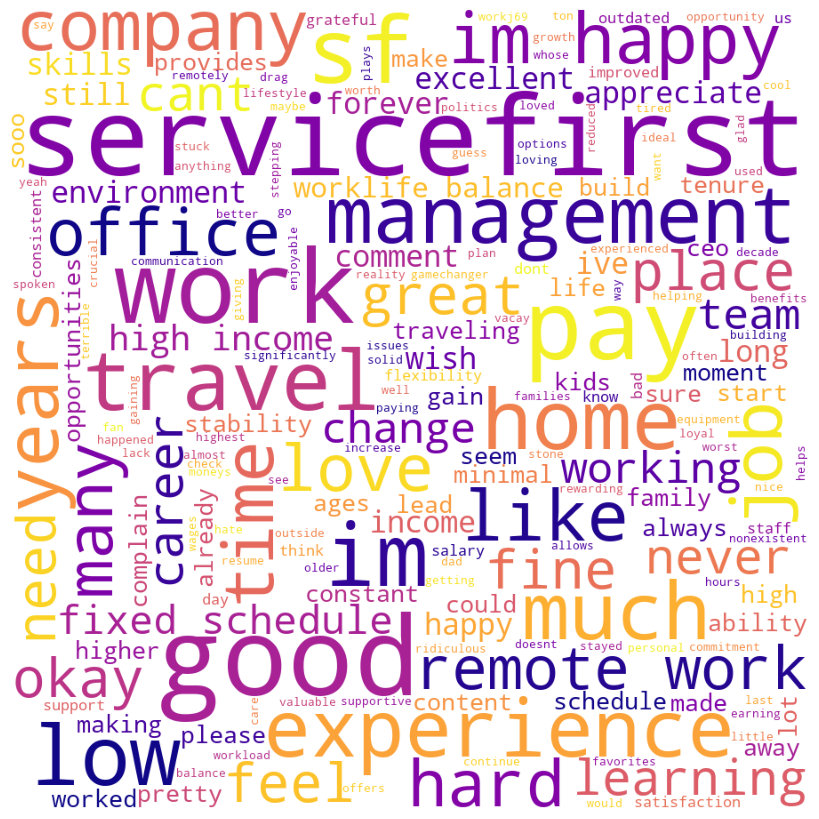

<Figure size 800x800 with 0 Axes>

In [225]:
# Set the colour palette.
sns.set(color_codes=True)

# Create a WordCloud.
wordcloud = WordCloud(width = 900,
                      height = 900, 
                      background_color ='white', 
                      colormap='plasma', 
                      stopwords = 'none', 
                      min_font_size = 10).generate(tokens2_string) 

# Plot the word cloud.                        
plt.figure(figsize = (8, 8),
           facecolor = None) 

plt.imshow(wordcloud) 
plt.axis('off') 
plt.tight_layout(pad = 0) 
plt.show()

# Save the word cloud as a PNG file.
plt.savefig('wordcloud_3.png')

# Note that your word cloud might differ slightly from the one provided.

## 5. Frequency distribution of words
Previously, we computed the frequently distributed tokens before we removed the stopwords. Now, we’ll compute the count of the most frequently used words. Follow these prompts to write the code:
- Create a new variable (e.g. `fdist1`) to store the `FreqDist()` class, and specify the `tokens2` variable as the target of the parameter. 
- Preview the data by calling the `fdist1` variable.

In [227]:
# View the frequency distribution.
fdist1 = FreqDist(tokens2)

# Preview the data.
fdist1

FreqDist({'work': 21, 'im': 18, 'good': 18, 'servicefirst': 17, 'pay': 13, 'sf': 12, 'low': 10, 'home': 10, 'travel': 10, 'happy': 10, ...})

> From the output, we can deduce that the token 'work' appears 21 times, while 'good' appears 18 times and 'pay' 13 times. 

The output is not particularly readable. Let’s convert it into a Pandas DataFrame. Follow these prompts to write the code:
- Import the `Counter` class from the `collections` library.
- Create a new variable (e.g. `counts`) to store the new Pandas DataFrame. 
- Specify the `pd.DataFrame(`) class and the following parameters:
  - Specify to use the `Counter` class on the `tokens2`. This is the DataFrame that doesn't contain stopwords and that contains only **relevant** tokens/words.
  - Add the `most_common()` method, and indicate `20`. 
  - Specify the column names of the DataFrame as `Word` and `Frequency`.
  - Set the index with `set_index()`, and specify `Word` as the measure of indexing.
- Preview the DataFrame.

In [234]:
# Import the Counter class.
from collections import Counter

# Generate a DataFrame from Counter.
counts = pd.DataFrame(Counter(tokens2).most_common(20),
                      columns=['Word', 'Frequency']).set_index('Word')

# Preview the data.
counts

,Frequency
Word,
work,21
im,18
good,18
servicefirst,17
pay,13
sf,12
low,10
home,10
travel,10


> Not all the words are reletive such as `im` and `sf`.     


Save the DataFrame as a CSV file for future reference. Use the code `counts.to_csv('counts.csv')`. Import the CSV file as a DataFrame, and view with the `head()` method.

In [236]:
# Save the output as a CSV file.
counts.to_csv('counts.csv')

# Import DataFrame to sense-check.
counts2 = pd.read_csv('counts.csv')

# View the DataFrame.
counts2.head()

,Word,Frequency
0,work,21
1,im,18
2,good,18
3,servicefirst,17
4,pay,13


Use visualisation to show the result.
- Create a new variable (e.g. `ax`) to store the `counts.plot()` function. Specify the following parameters:
  - `kind='barh'`: create a barplot
  - `figsize=(8, 8)`: size of the plot
  - `fontsize=12`: the font size on the plot
  - `colormap='plasma'`: colour palette to apply
- Specify the labels of the axis (`set_ylabel` and `set_xlabel`) and the `set_title` of the chart. 
- Set the fontsize of the labels and title to `12` and `20` respectively.
- Customise the plot by adding labels for each bar to indicate the frequency of the word.
  - Use a `for` loop and `i` as the iterator.
  - Specify `ax.patches` as the data to iterate through.
  - `i` represents each bar in the chart.
  - Apply the `test()` function to the `ax` variable we create to store the `countplot()` method.
  - The following parameters will apply:
   - `get_width()` and `get_y()` functions to set the bar sizes.
   - Add labels with the `str()` function, and round the numbers to two decimal places with the `round()` function based on the width of each bar.
   - Specify the `color='red'`.
- Save the visualisation as a PNG file for future reference.

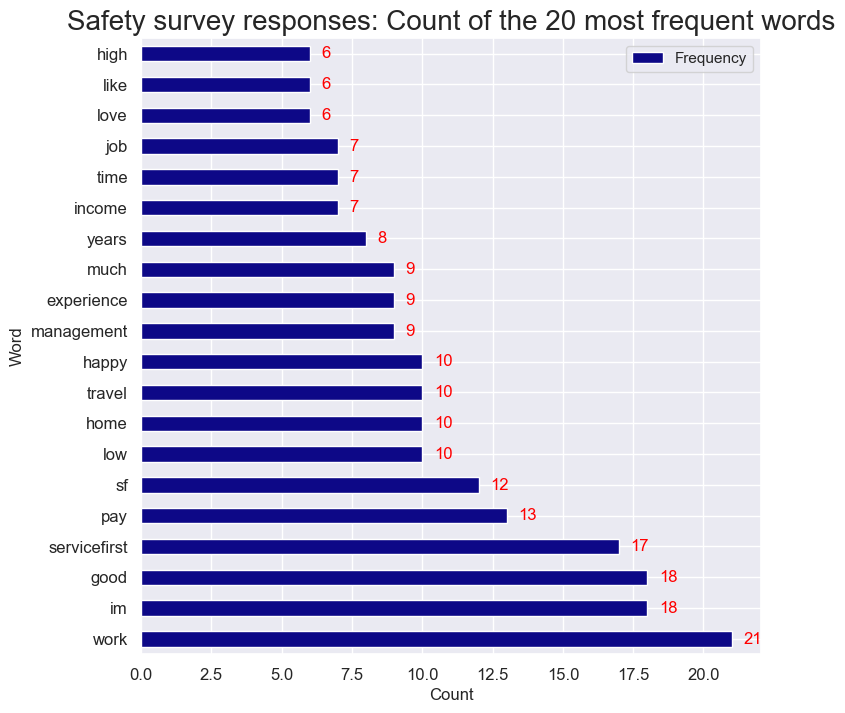

In [238]:
# Set the plot type.
ax = counts.plot(kind='barh',
                 figsize=(8, 8),
                 fontsize=12,
                 colormap ='plasma')

# Set the labels.
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
ax.set_title("Safety survey responses: Count of the 20 most frequent words",
             fontsize=20)

# Draw the bar labels.
for i in ax.patches:
    ax.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
            fontsize=12, color='red')
    
# Save the plot as a PNG file.
plt.savefig('frequent_words.png')


> From the output, we can deduce that the token 'work' appears 21 times, while 'good' appears 18 times and 'pay' 13 times.

## 6. Review polarity and Sentiment

 
Follow these prompts to write the code:
- Import `TextBlob` from `textblob`.
- Create a user-defined function to extract a polarity score for all the `Review`. 
- Use the `def` keyword, and name the function `generate_polarity` with the `commReviewent` variable as an argument. 
- Use the function to `return` the output of the `TextBlob` class, specifying the `comment` variable in the parameters and applying the `sentiment()` method. Specify `[0]` to return the first item in the output for sentiment.
- In the main program, declare a new column named `polarity` in the `survey` DataFrame, and assign it the output of the `generate_polarity` function as applied to the `Review` column.
- Display a preview of the newly populated `polarity` column using the `head()` method.

In [240]:
# Import the necessary package.
from textblob import TextBlob

# Define a function to extract a polarity score for the comment.
def generate_polarity(Review):
    return TextBlob(Review).sentiment[0]

# Populate a new column with polarity scores for each comment.
sentiment['polarity'] = sentiment['Review'].apply(generate_polarity)

# Preview the result.
sentiment['polarity'].head()

0    0.0
1    0.8
2    0.5
3    0.3
4    0.0
Name: polarity, dtype: float64

The function works by extracting the relevant score from the sentiment method for each comment. Let’s do the same to return the subjectivity score as the **second** element (`index=1`). Follow these prompts to write the code:
- Use the `def` keyword, and name the function `generate_subjectivity` with the `comment` variable as an argument. 
- Use the function to `return` the output of the `TextBlob` class, specifying the `comment` variable in the parameters and applying the `sentiment()` method. Specify `[1]` to return the second item in the output for sentiment.
- In the main program, declare a new column named `sentiment` in the `survey` DataFrame, and assign it the output of the `generate_subjectivity` function as applied to the `Comments` column.
- Display a preview of the newly populated `subjectivity` column using the `head()` method.

In [246]:
# Define a function to extract a subjectivity score for the comment.
def generate_subjectivity(Review):
    return TextBlob(Review).sentiment[1]

# Populate a new column with subjectivity scores for each comment.
sentiment['subjectivity'] = sentiment['Review'].apply(generate_subjectivity)

# Preview the result.
sentiment['subjectivity'].head()

0    0.30
1    0.75
2    0.60
3    0.00
4    0.00
Name: subjectivity, dtype: float64

> The function works by extracting the relevant score from the sentiment method for each comment. While the outputs of polarity and sentiment can be hard to interpret, we’ve added these results as new columns in the original safety DataFrame for easier analysis.

If you save the DataFrame to a CSV file, you can peruse the data in Excel, for example. Follow these prompts to write the code:
- Specify the DataFrame as `safety` and the `to_csv()` function.
- Specify the name of the CSV file as `safety2`.
- Import the DataFrame with `pd.read_csv()` function, and view the DataFrame with the `head()` method.

In [248]:
# Save the output as a CSV file.
sentiment.to_csv('sentiment2.csv')

# Import the DataFrame to sense-check.
sentiment2 = pd.read_csv('sentiment2.csv')

# View the DataFrame.
sentiment2.head()

,Unnamed: 0,index,Review,tokens,polarity,subjectivity
0,0,0,stuck with low wages for years management does...,"['stuck', 'with', 'low', 'wages', 'for', 'year...",0.0,0.30
1,1,1,servicefirst is a great start for my career le...,"['servicefirst', 'is', 'a', 'great', 'start', ...",0.8,0.75
2,2,2,im learning a ton here love it,"['im', 'learning', 'a', 'ton', 'here', 'love',...",0.5,0.60
3,3,4,ive been with servicefirst for over a decade a...,"['ive', 'been', 'with', 'servicefirst', 'for',...",0.3,0.00
4,4,5,i feel like i never see my kids because im alw...,"['i', 'feel', 'like', 'i', 'never', 'see', 'my...",0.0,0.00


 

Create a histogram (visualisation) to view the data.

- Set the number of bins to `50` (e.g. `num_bins=50`). 
- Set the plot area with the `figure()` method and` figsize` parameter as `8, 8`.
- Create a new variable (e.g.` n, bins, patches`) to store the `hist()` function, and set the parameters as:
  - `sentiment['polarity']`: the column to use as data
  - `num_bins`: referring back to the variable created
  - `facecolor='blue'`: the colour of the bins
- Set the labels and title of the histogram to have a font size of `12` and `20` respectively.
- View the histogram.
- Save the histogram as a PNG file.

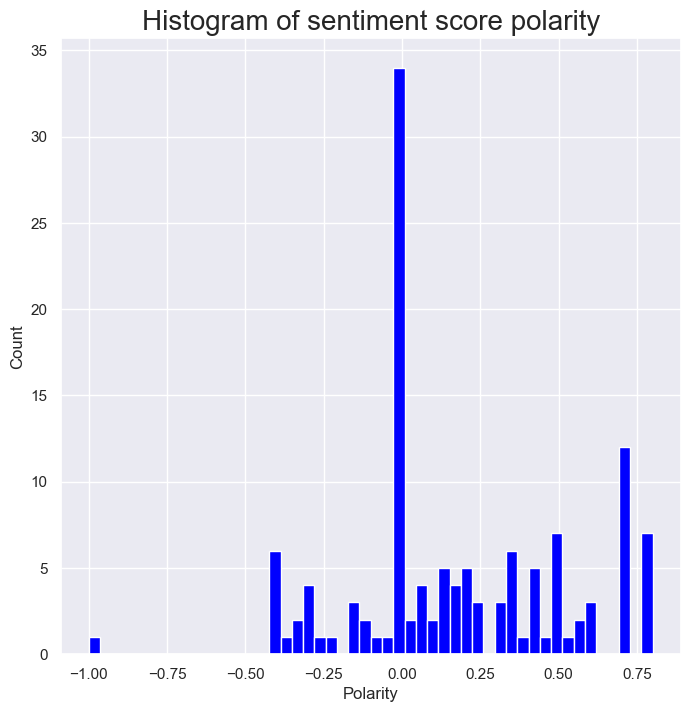

<Figure size 800x800 with 0 Axes>

In [252]:
# Set the number of bins.
num_bins = 50

# Set the plot area.
plt.figure(figsize=(8, 8))

# Define the bars.
n, bins, patches = plt.hist(sentiment['polarity'],
                            num_bins,
                            facecolor='blue')
                            
# Set the labels.
plt.xlabel('Polarity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score polarity', fontsize=20)

plt.show()

# Save the plot as a PNG file.
plt.savefig('polarity.png')

> **This plot indicates that most reviews are clustered around neutral, showing little to no strong sentiment to positive.**

Create another histogram based on `subjectivity`.

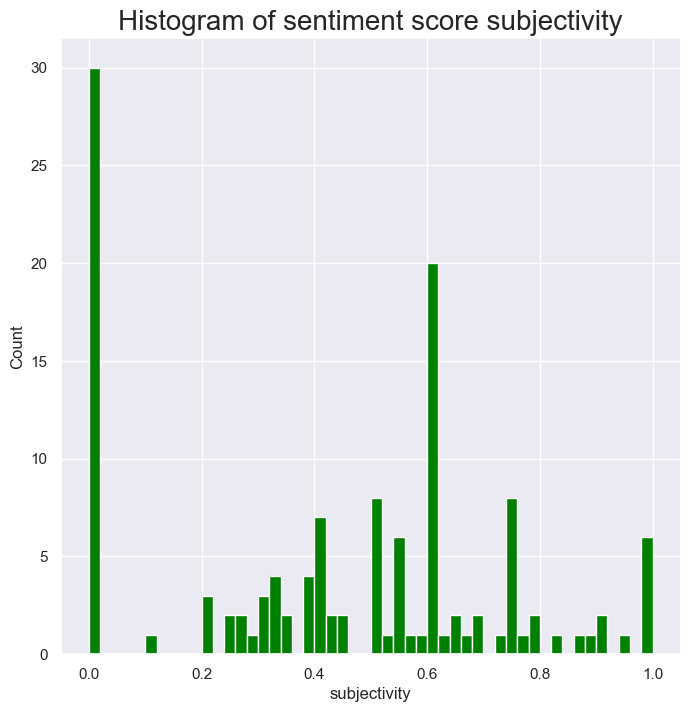

<Figure size 800x800 with 0 Axes>

In [256]:
# Set the number of bins.
num_bins = 50

# Set the plot area.
plt.figure(figsize=(8, 8))

# Define the bars.
n, bins, patches = plt.hist(sentiment['subjectivity'],
                            num_bins,
                            facecolor='green')
                            
# Set the labels.
plt.xlabel('subjectivity', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Histogram of sentiment score subjectivity', fontsize=20)

plt.show()

# Save the plot as a PNG file.
plt.savefig('subjectivity.png')

>**Histograms reveal that most Reviews are centred around zero, indicating a strong level of objectivity in the feedback. From the two histograms, we can infer that the majority of responses are neutral or show little sentiment, with a few Reviews leaning toward more positive. These observations suggest that the overall tone of the Reviews may be more balanced with a slight lean towards positive, rather than highly polarized.**

## 7. Extract contextualised comments
The approach for determining positive polarity is similar to that for negative polarity. Start by exploring how to extract positive polarity, and then you can apply your understanding to write the code for extracting negative polarity.

### Positive polarity
Follow these prompts to write the code:
- Declare a `positive_sentiment` DataFrame that is a subset of the `safety` DataFrame. Use the `nlargest(20, 'polarity')` function and parameters to extract the rows with the `20` highest values under the `polarity` column. (**Hint:** You can use any number; but for now, we’ll stick to 20.)
- Eliminate unnecessary data by redefining the `positive_sentiment` DataFrame as containing only the `Comments`, `polarity`, and `subjectivity` columns.
- Adjust the `Review` column for better readability using the `style.set_properties()` method. Specify `**{'width': '1200px'}` to apply the adjustment to the entire column. 
- Save the output as a CSV file, and view the DataFrame with the `shape` and `head()` methods.

In [261]:
# Create a DataFrame with top 20 positive comments.
positive_sentiment = sentiment.nlargest(20,
                                     'polarity')

# Eliminate unnecessary columns.
positive_sentiment = positive_sentiment[['Review',
                                         'polarity',
                                         'subjectivity']]

# Adjust the column width.
positive_sentiment.style.set_properties(subset=['Comments'],
                                        **{'width': '1500px'})

# Save the output as a CSV file.
positive_sentiment.to_csv('positive_sentiment.csv')

# View the shape of the DataFrame.
print(positive_sentiment.shape)
positive_sentiment.head(20)

(20, 3)


,Review,polarity,subjectivity
1,servicefirst is a great start for my career le...,0.8,0.75
9,great place to gain experience,0.8,0.75
13,servicefirst is giving me great experience,0.8,0.75
66,i would say im happy,0.8,1.00
77,im happy with sf,0.8,1.00
103,pay isnt great,0.8,0.75
108,salary could use an upgrade lol,0.8,0.70
6,getting good experience here,0.7,0.60
14,its good,0.7,0.60
32,no comment its a good job,0.7,0.60


> The output indicates the top 20 positive `Review` by `polarity` and `subjectivity` . 


>Based on the reviews, the major factors affecting employee satisfaction seem to be experience and pay. Phrases like "**great experience**," "**good pay**," and "**salary could use an upgrade**" indicate that employees appreciate opportunities for career growth and financial compensation. Positive comments such as "**great start for my career**," "**happy with SF**," and "**good place to build skills**" also suggest that employees value the work environment and learning opportunities.

>Therefore, employee satisfaction is influenced by a combination of career development, pay, and the overall work culture at ServiceFirst.

>However, mistakes like "pay isn't great" being classified as positive polarity suggest that the model may not be 100% accurate. Apart from this, the other reviews appear to be classified correctly.



In [264]:
print(positive_sentiment.index)


Index([1, 9, 13, 66, 77, 103, 108, 6, 14, 32, 34, 42, 49, 50, 57, 58, 65, 81,
       129, 7],
      dtype='int64')


> Lets check index `13` for example:

In [267]:
positive_sentiment.at[13, 'Review']

'servicefirst is giving me great experience'

> Above example shows the positive sentiment as prediceted. 

### Negative polarity

In [270]:
# Create a DataFrame with the top 20 negative comments.
negative_sentiment = sentiment.nsmallest(20,
                                      'polarity')

# Eliminate unnecessary columns.
negative_sentiment = negative_sentiment[['Review',
                                         'polarity',
                                         'subjectivity']]

# Eliminate unnecessary columns.
negative_sentiment.style.set_properties(subset=['Comments'], 
                                        **{'width': '1500px'})

# Save the output as a CSV file.
negative_sentiment.to_csv('negative_sentiment.csv')

# View the shape of the DataFrame.
print(negative_sentiment.shape)
negative_sentiment.head(20)

(20, 3)


,Review,polarity,subjectivity
43,office politics are the worst,-1.000000,1.000000
61,the equipment we work with is outdated,-0.400000,0.633333
8,been here forever but the pay is still terribl...,-0.400000,0.600000
29,im not happy ive spoken to my team lead about ...,-0.400000,1.000000
83,been here forever but the lack of career growt...,-0.400000,0.900000
95,company policies are outdated and inflexible,-0.400000,0.616667
122,team collaboration is poor,-0.400000,0.600000
71,management is not good at all they are not exp...,-0.375000,0.750000
48,the ceo is not good please change him,-0.350000,0.600000
47,the workload is ridiculous,-0.333333,1.000000


In [272]:
negative_sentiment.at[122, 'Review']

'team collaboration is poor'

> The output indicates the top 20 Negative `Review` by `polarity` and `subjectivity` .
> 
>**Management Issues:** Multiple comments highlight dissatisfaction with management, such as "management is hard to talk to and unavailable," "the CEO is not good, please change him," and "never any recognition for hard work." These indicate that employees feel unsupported and undervalued by the leadership.

>**Workplace Conditions:** Comments like "office politics are the worst," "the workload is ridiculous," and "the equipment we work with is outdated" point to frustrations with the work environment and resources.

>**Work-Life Balance:** Statements like "hard to balance work and family" and "I hate being away from home so much" show that employees are struggling with achieving a healthy work-life balance.

>**Career Growth and Recognition:** "Lack of career growth" and "no opportunities for remote work" suggest that employees are dissatisfied with limited professional development and flexibility in their roles.

>**Pay:** "Years of hard work still low pay" indicates dissatisfaction with compensation, suggesting that employees feel their work is not being adequately rewarded.

>These areas of dissatisfaction point to significant issues that can affect employee retention, highlighting the need for better management practices, resource allocation, and career development opportunities.

>While the model seems to classify negative sentiment accurately for most reviews, there may still be some margin for improvement, as some reviews, like "**average**," have a very low polarity score but might still contain elements of dissatisfaction that are not fully captured by the model.

## 8. Identify named entities
Identifying named entities helps extract key information like names, places, and dates from text. This improves data organization, enhances sentiment analysis, and allows for better search, recommendations, and content personalization.



- Import the spaCy library as `spacy`.
- Create a new variable (e.g. `nlp`) to store the `spacy.load()` method. Inside the brackets, specify the English resource to use as `'en_core_web_sm'`. There are various English resources available, but we’ll use the one developed specifically for websites. Each of the English resources is tailor-made to accommodate a particular language variety, including unique words, etc. 
- Create a user-defined function to return the text snippet and its corresponding entity label in a list. This function will extract the entities and corresponding labels for each survey comment. 
  - Use the `def` keyword, and name the function `generate_named_entities` with the `Review` variable as an argument. 
  - In the function, `return` a nested list that contains two items: an inner list of entities from the supplied comment and a label for the comment.  
  - Use a list comprehension to generate the list. Specify `ent` as the iterator. Apply the `text.strip()` function to the iterator to extract the inner list items and the `label_ function` to extract the label. Iterate through the data in `nlp(Review).ents`.
- Specify the entities for each comment to be populated in a new column called `named_entities` by applying the `generate_named_entities()` function to the `Review` column. An empty list will be returned for comments where a proper noun is not identified. 
- Preview the DataFrame, and scroll to the rightmost column.


In [276]:
# Import the spaCy library.
import spacy

# Load the English resource.
nlp = spacy.load('en_core_web_sm')

# Return the text snippet and its corresponding entity label in a list.
def generate_named_entities(Review):
    return [(ent.text.strip(), ent.label_) for ent in nlp(Review).ents]

sentiment['named_entities'] = sentiment['Review'].apply(generate_named_entities)

# View the output.
sentiment.head()

,index,Review,tokens,polarity,subjectivity,named_entities
0,0,stuck with low wages for years management does...,"[stuck, with, low, wages, for, years, manageme...",0.0,0.30,"[(years, DATE)]"
1,1,servicefirst is a great start for my career le...,"[servicefirst, is, a, great, start, for, my, c...",0.8,0.75,[]
2,2,im learning a ton here love it,"[im, learning, a, ton, here, love, it]",0.5,0.60,[]
3,4,ive been with servicefirst for over a decade a...,"[ive, been, with, servicefirst, for, over, a, ...",0.3,0.00,[]
4,5,i feel like i never see my kids because im alw...,"[i, feel, like, i, never, see, my, kids, becau...",0.0,0.00,[]


The output indicates the named entities. 

Create a visualisation. Follow these prompts to write the code:
- Import `displacy` from the spaCy library.
- Iterate through the elements in the `named_entities` column using a `for` loop.
  - Use i as the iterator and the `range()` function to iterate through, specifying 10 and 20 in the parameters as the sample range. 
  - Check whether the item at position `i` under `named_entities` contains data using a conditional `if` statement.
  - If the conditional statement is `True`, display the entities using the `displacy.render()` function. For the source data, use the`nlp(sentiment['Review'][i])` function, specify the `style='ent'`, and `Juptyer=True`. The Jupyter parameter indicates to Python that the output will be generated within Jupyter Notebook.

In [278]:
from spacy import displacy

# Iterate through a selection of comments. Specify the index of comments.
for i in range(10, 20):
    # Check whether the corresponding comment has a named entity.
    if sentiment['named_entities'][i]:
        # Highlight the entity in the comment.
        displacy.render(nlp(sentiment['Review'][i]), style='ent', jupyter=True)        

>No named entities found in Reviews.


## 9. Generate a document-term matrix
Document-Term Matrix (DTM) onvert text data into a structured format, allowing for easier analysis of word frequency and relationships across documents. It helps in identifying patterns, performing clustering, and applying machine learning models like classification or topic modeling.

Create a document-term matrix (DTM) using the bag-of-words model, which converts text into a matrix showing word occurrences. Each survey response is treated as a document. Using scikit-learn's CountVectorizer, we’ll prepare the comments, set parameters, and identify frequently used words.


### a) Prepare the comments
Follow these prompts to write the code to prepare the comments:
- Import the `CountVectorizer` class from the `sklearn.feature_extraction.text` module and the `RegexpTokenizer` class from the `nltk.tokenize` module.
- Create a `token` object of the `RegexpTokenizer` class. Specify a regular expression of `r'[a-zA-Z0-9]+'` in the class parameters so that the object will extract tokens according to the presence of the given characters in the expression.
- Create a `cv` object of the `CountVectorizer` class. In the parameters, specify to return lowercase tokens, use stopwords from the  English word list, `ngram_range = (1,1)` to return individual word tokens, and use the `token` object for tokenising.
- Prepare the Review by applying the `fit.transform()` method to the `cv` object, specifying the `sentiment['Review']` data in the parameters, and assign the output to a new `cvs` object.

In [281]:
# Import the necessary classes.
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer

# Use a tokenizer object to remove unwanted elements.
token = RegexpTokenizer(r'[a-zA-Z0-9]+')

# Create a CountVectorizer object to process the comments.
cv = CountVectorizer(lowercase=True,
                     stop_words='english',
                     ngram_range = (1, 1),
                     tokenizer = token.tokenize)

# Apply the transformation to the comment data.
cvs= cv.fit_transform(sentiment['Review'])

> No output was returned, confirming that the comments have been successfully prepared.

### b) Set the parameters
For this demonstration, we'll focus on the first 15 reviews (Review). If you're comfortable with the Bag-of-Words (BOW) model.

- Create a DataFrame named `dt`. In the parameters, specify `cvs.todense()` to base the DataFrame on the `cvs` object and include empty values in the new DataFrame. Use `iloc[:15]` to extract only the first 15 records. 
- Populate the column names using the `get_feature_names()` method applied to the `cv` object.
- Transpose a new DataFrame `document_term_matrix` based on `dt` but with transposed columns and rows, by applying the `T` property to the `dt` DataFrame.
- Update the column names in `document_term_matrix` by using a list comprehension that iterates through the range of 1 to 16 (15 times). For each column, add the string value of the current column name to `'Doc'` using the `+` operator.
- Add a row to `document_term_matrix` named `'total_count'`, and give it values by applying the `sum` method to the DataFrame. In the method parameters, specify that `axis=1` to `sum` the columns.
- Reorder the rows by applying the `sort_values()` method. Specify `total count` as the sorting criterion, `ascending` as `False`, and use a `slice [:20]` to extract the first 20 records. (**Hint:** You can play around with this number to increase or decrease the number of words.)
- Display the top 10 word results for the first 15 documents in `document_term_matrix` using a `print()` statement. In the parameters, apply the `drop()` method to the DataFrame to show the `total_count` column and the `head(10)` method to display the first 10 results.

In [283]:
# Create a DataFrame.
dt = pd.DataFrame(cvs.todense()).iloc[:15]  

# Name the columns.
dt.columns = cv.get_feature_names_out()

# Transpose columns and headings.
document_term_matrix = dt.T

# Update the column names.
document_term_matrix.columns = ['Doc '+str(i) for i in range(1, 16)]

# Get the totals.
document_term_matrix['total_count'] = document_term_matrix.sum(axis=1)

# Identify the top 10 words. 
document_term_matrix = document_term_matrix.sort_values(by ='total_count', 
                                                        ascending=False)[:20] 

# Display the results.
document_term_matrix.drop(columns=['total_count']).head(10)

,Doc 1,Doc 2,Doc 3,Doc 4,Doc 5,Doc 6,Doc 7,Doc 8,Doc 9,Doc 10,Doc 11,Doc 12,Doc 13,Doc 14,Doc 15
experience,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0
servicefirst,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0
low,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0
learning,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0
pay,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0
great,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
good,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
work,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0
im,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0
travel,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0


The DTM shows that each row corresponds to a unique word found across the responses, while the columns represent individual survey responses.

Follow the steps:

- Specify the DataFrame as `document_term_matrix` and add the `to_csv()` method.
- Inside the brackets, specify the file name as `dtm.csv`.
- Import the CSV file as a DataFrame and view the DataFrame with the `head()` method.

In [285]:
# Save as a CSV file for further analysis/research.
document_term_matrix.to_csv('dtm.csv')

# Import DataFrame to sense-check.
dtm = pd.read_csv('dtm.csv')

# View the DataFrame.
dtm.head()

,Unnamed: 0,Doc 1,Doc 2,Doc 3,Doc 4,Doc 5,Doc 6,Doc 7,Doc 8,Doc 9,Doc 10,Doc 11,Doc 12,Doc 13,Doc 14,Doc 15,total_count
0,experience,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,4
1,servicefirst,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,4
2,low,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,3
3,learning,0,1,1,0,0,0,0,1,0,0,0,0,0,0,0,3
4,pay,0,0,0,0,0,0,0,0,1,0,0,1,1,0,0,3




### c) Identify frequently used words
Identify the most frequently used words across the responses. Create a horizontal bar plot based on the total_count data, using code similar to what we’ve used before. Here's how to proceed:

- Create a new variable (e.g. `ax2`) to store the `plot()` function based on the `document_term_matrix['total_count']` DataFrame and column. Specify the following parameters:
  - `kind='barh'`: create a barplot
  - `figsize=(8, 8)`: size of the plot
  - `fontsize=12`: the font size on the plot
  - `colormap='plasma'`: colour palette to apply
- Specify the labels of the axis (y and x) and the title of the chart. 
- Set the font size of the labels and title to `12` and `16` respectively.
- Customise the plot by adding labels for each bar indicating the count of the word.
  - Use a `for` loop and `i` as the iterator.
  - Specify `ax2.patches` as the data to iterate through.
  - `i` represents each bar in the chart.
  - Apply the `test()` function to `ax2` variable we created to store the `countplot()` method.
  - The following parameters will apply:
   - `get_width()` and `get_y()` functions to set the bar sizes.
   - Add labels with the `str()` function and round the numbers to two decimal places with the `round()` function based on the width of each bar.
  - Specify the `color='red'`.
- Save the visualisation as a PNG file for future reference.

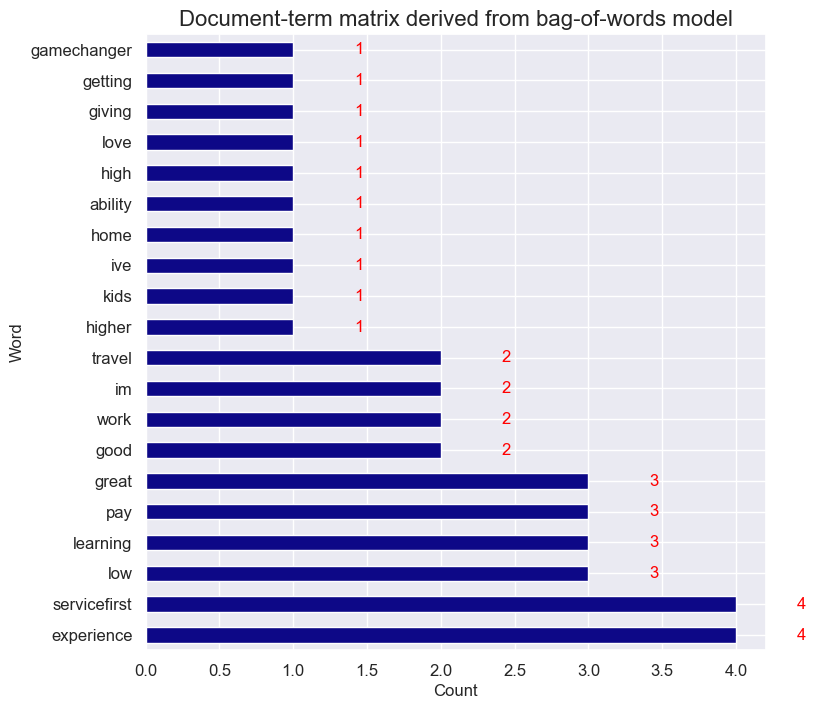

In [287]:
# Set the plot type.
ax2 = document_term_matrix['total_count'].plot(kind='barh',
                                              figsize=(8, 8),
                                              fontsize=12,
                                              colormap ='plasma')

# Set the labels.
ax2.set_xlabel('Count', fontsize=12)
ax2.set_ylabel('Word', fontsize=12)
ax2.set_title("Document-term matrix derived from bag-of-words model",
             fontsize=16)

# Draw the bar labels.
for i in ax2.patches:
    ax2.text(i.get_width()+.41, i.get_y()+.1, str(round((i.get_width()), 2)),
             fontsize=12, color='red')
    
# Save the plot as a PNG file.
plt.savefig('dtm.png')


**Frequent Terms:** “Experience” and “ServiceFirst” are the most mentioned, indicating focus on employee experience.

**Work-Related Factors:** Words like “pay,” “learning,” and “work” suggest employees are concerned about compensation and growth opportunities.

**Positive Sentiment:** Terms like “good” and “great” reflect satisfaction with work conditions.

**Personal Factors:** Personal words like “home” and “kids” appear less often, indicating less focus on personal aspects.

### Share Finding 

Data Wrangling (2 missing values and 10 duplicate rows was removed) has been done and unnecessary columns were droped (all the columns except Reveiw).

Preprocess such as **change to lower case** , **remove punctuation** has been done to the data.

Next Data has been visualised with and without `Stopwords`.

**Tokenised*** the review column to find the most frequent words(using nltk library).

Before removing the stopwords, `the` was the most frequent word, appearing 42 times. After the stopword elimination process, `work` became the most frequent word, appearing 21 times. **Stating how removing stopwords can add meaning and accuracy to the analysis.**

The polarity and subjectivity were then analyzed using the TextBlob library. The results were visualized and saved for future reference.

Positive and Negative Polarity was checked along with the reviews.

Identified named entities to helps extract key information like names, places, and dates from text. **No named entities was detected**.

A Document-Term Matrix (DTM) is generated to convert text data into a structured format, allowing for easier analysis of word frequency and relationships across documents and to help in identifying patterns.Words such as `exprience` and `servicefirst` have the most counts.Indication that exprience (Total working years might play a role in satisfaction).

**Conclusion:**

The reviews mainly emphasize work-related factors and **employee experience**, with **pay** , **management** and **learning opportunities** being key concerns.

The majority of reviews are centered around a neutral sentiment, with minimal expression of strong positive or negative feelings, indicating a **high degree of objectivity in the feedback**.

Based on the polarity and subjectivity histograms, it is evident that **most responses are neutral** or **display weak sentiment**, with only a few reviews leaning toward more positive. This suggests that the **overall tone of the Reviews maybe more balanced with a slight lean towards positive, rather than highly polarized**.

These observations suggest that the overall tone of the Reviews may be more balanced with a slight lean towards positive, rather than highly polarized.

# **Employee Satisfaction and Retention Analysis**

ServiceFirst is a national equipment servicing company with **250 employees**, including both **remote and office-based staff**. Following the pandemic, the company has faced:

- High staff turnover
- Increased recruitment costs
- Loss of in-house experience

To address these challenges, the **People & Culture (P&C) team** conducted an **employee survey** to measure **satisfaction and organizational climate perceptions**. The goal is to apply **advanced analytics such as  clustering ,classification , decision tree and sentiment analysis models** to identify key drivers of satisfaction and **uncover factors influencing employee retention**.

**Business objectives:** What are the key drivers for employee satisfaction?

---

## **Dataset Overview**


The dataset contains `142` records and `9` columns.

The `"Review"` column (open-ended feedback) has `2` missing values.

The dataset includes categorical (e.g., Business Travel, Education, Gender) and numerical (e.g., Age, Monthly Income, Satisfaction Score) data.

The `"satisfaction_score"` column is an important metric representing overall employee satisfaction.

The `"MonthlyIncome (K)"` column represents income in thousands.

The `"Review"` column contains textual feedback that will be useful for sentiment analysis.

---

### **Descriptive Statistics**

Average Age:` ~37 years`

Average Monthly Income: `~8.35K`

Average Experience: `~13.44 years`

Average Satisfaction Score: `~59.49 `(out of 100)

Visualization has been done to check Data distibution and outlier using Box plot and histogram.


---

## **Data Wrangling & Cleaning**

- **Checked for missing and duplicate values** `2 `missing value and `10` duplicate rows were found for `Review` column which was removed for sentiment analysis.
  
- **Converted categorical variables (`Business Travel`,`Education`,`Gender`)** into numerical representations using `LabelEncoder()` method for further modlleing.
- **Renamed necessary columns for better readibility** for example `'MonthlyIncome (K)'`:`'Income'`.

- **Dropped unnecessary columns**: for different model dropped the unnecessary columns. for instance :` Kmeans clustering` and `decision tree`,columns : `Rowid` and `Review`were dropped. For `sentiment amalysis` : all the columns except `Review`were dropped.

  

---

## **Data Preprocessing** 
Data Preprocessing has been done separately for each modeling programes.

- **Normalised the data using StandardScaler** to ensures all features are on the same scale and prevents variables with larger numerical ranges (e.g., `income`) from dominating smaller-range variables (e.g., `satisfaction score`).(important for clustering algorithms like K-Means)

- Checked the **correlation**, so we can select the variables that strongly are related , improving the clustering process by ensuring meaningful and distinct clusters.In this case, `Income` was used due to its higher correlation with the `Satisfaction Score`, making it more relevant for clustering.

- Preprocess data for sentiment analysis such as **change to lower case** , **remove punctuation** has been done to the data.

  
## **Hypothesis Testing**
Two hypotheses were tested using **A/B Testing (t-tests)**:

By using the median to split the income, we ensure that each group contains an equal number of employees, minimizing the potential bias from extreme income values. This division simplifies the comparison of satisfaction scores between two distinct groups (low-income vs high-income employees).

The **Independent t-test** is appropriate in this scenario because we are comparing the means of **two independent groups**: high-income employees and low-income employees. The test evaluates whether there is a statistically significant difference between the two groups' satisfaction scores. The assumptions of the t-test (e.g., normal distribution, equal variance) can be checked with preliminary data analysis (e.g., normality tests).

1. **High vs Low income Employees:** **There is no statistically significant difference in satisfaction scores between High and Low income employees**.

> Due to no significant difference is found, ServiceFirst might explore other factors that contribute to employee satisfaction, such as work environment, career development opportunities, or leadership quality.

2. **High vs Low exprienced:** **There might be a slight increase in satisfaction with experience, but the relationship may not be statistically significant.**.


> The test shows that employees with more experience are significantly more satisfied, the company may focus on retaining experienced employees by offering career advancement opportunities, recognition, and rewards for their loyalty and expertise.

---


# **Modelling**

## **Kmeans Clustering**

K-Means is ideal for unsupervised clustering, allowing us to group employees based on unsupervised patterns in their data. It's a simple and efficient algorithm for unsupervised learning that helps identify patterns or segments in data, making it useful for tasks like customer segmentation, anomaly detection, and market analysis.
Clustering is used to group employees based on similar characteristics. For example, employees with similar satisfaction scores, years of service, and income might be grouped into the same cluster. K-Means is used here for its simplicity and efficiency.

Used pairplot() to helps visualize correlations between variables through scatter plots and correlation patterns (based on Income and Satisfaction Score).

Visually, it was apparent that the data could be divided into four segments. To gain a clearer understanding of the optimal number of segments, the Elbow and Silhouette methods were applied to find the better fit.

- **K value = 3 using elbow method** 
- **K value = 4 using Silhouette method**
  
  Based on the results from both methods, the KMeans clustering algorithm was applied and visualized, with **K = 4** identified as the optimal number of clusters with minimal or no soft margin.
  
| **K-Means** | **Predicted** |
|------------- |-------------- |
| 1           | 60            |
| 2           | 39            |
| 0           | 25            |
| 3           | 18            |

>It seems that **Cluster 1** has the highest number of observations, while **Cluster 3** has the least. The imbalance between the clusters may suggest some clusters are more dominant or representative of the overall dataset, and the smaller clusters (like Cluster 3) could represent specific niche groups that may require a different approach. In this case employees with high income and yet low satisfaction. 

**Cluster 0:** High satisfaction and high income—likely the most loyal and engaged employees.

**Cluster 1:** Moderate satisfaction but lower income—happiness likely stems from factors beyond income (e.g., work environment).

**Cluster 2:** Low satisfaction and low income—high risk of turnover; requires immediate intervention.

**Cluster 3:** Low satisfaction but higher income—dissatisfaction may be due to factors other than income (e.g., work environment).



>The clusters are well-separated, with **higher-income groups generally showing higher satisfaction scores**, while **lower-income groups tend to have lower satisfaction scores**.However, this doesn't necessarily mean that higher income always leads to higher satisfaction.By addressing the specific needs of each cluster, the company can improve retention and overall employee satisfaction.

---

## **Decision Tree**

The **Decision Tree** is chosen for classification because it handles both categorical and numerical data well and offers interpretability.

**Decision tree is used to classify employees based on whether they are likely to stay or leave the company based on features such as age, income, and satisfaction score.**

The dataset was split into a **80:20 train-test ratio**.
Since the data has been normalised previously(`satisfaction_score > =50` is considered as `Satisfied` and a `satisfaction_score <=49` is considered as Dissatisfied) now `satisfaction score >= 0` considered as` Sitisfied` and  `satisfaction score < 0` considerd as `Dissatisfied`. (Converted Satisfaction Score into a binary classification target) 

Data has been splited accordingly:

**Features (X)**: `Business Travel`, `Education`, `Gender`, `Age`, `Income`, `Working Years`.

**Target (y)**: `Overall Satisfaction` (1 = Satisfied, 0 = Dissatisfied).

Next visualised the data using Matplotlib for better understanding and finally the model been evaluated using confusion matrix.


| **Class** | **Precision** | **Recall** | **F1-Score** | **Support** |
|-----------|---------------|------------|--------------|-------------|
| 0         | 1.00          | 1.00       | 1.00         | 11          |
| 1         | 1.00          | 1.00       | 1.00         | 18          |

**Precision (How many predicted positives were actually correct?)**

Class 0: 1.00 → All predictions for "Dissatisfied" were correct.

Class 1: 1.00 → All predictions for "Satisfied" were correct.

**Recall (How many actual positives were correctly identified?)**


Class 0: 1.00 → All actual "Dissatisfied" cases were predicted correctly.

Class 1: 1.00 → All actual "Satisfied" cases were predicted correctly.

**F1-score (Harmonic mean of Precision & Recall)**

Class 0: 1.00 → Perfect balance between precision and recall.

Class 1: 1.00 → No misclassifications.

**Support (Number of actual instances in each class)**

Class 0 (Dissatisfied): 11 cases in test data.

Class 1 (Satisfied): 18 cases in test data.

The model achieved `100%` accuracy, meaning it perfectly classified employees as Satisfied (score ≥ 50) vs. Dissatisfied (score < 50) in the test set.

The classification report shows perfect `precision`, `recall`, and `F1-score` for both classes.

The confusion matrix confirms that no misclassifications occurred.

However, this might indicate **overfitting** since the dataset is relatively small and everything is perfectly 100%.

>**According to the decision tree, `Age` and `Work Travel` appear to have the greatest influence on the overall score, as the model uses them as key splitting criteria in the decision-making process.** 

For Example :

Bracnh : `Business Travel <= 0.5` , `Age <= 0.88` , `Income <= 0.338` ---> Satisified.

Branch : `Business Travel <= 1.5` , `Income <= -0.91` ---> Disatisfied

After Prunning and Balancing weight of the samples:



| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0 (Dissatisfied) | 0.92 | 1.00 | 0.96 | 11 |
| 1 (Satisfied)    | 1.00 | 0.94 | 0.97 | 18 |



**Accuracy**: 97%

**Macro Avg F1-Score**: 0.96

**Weighted Avg F1-Score**: 0.97


It makes **no false negatives** for **dissatisfied employees** (Recall = 1.00 for Class 0).

It has only **one misclassification** for **satisfied employees**.

The model is well-generalized and **not overfitting**.

**Business Travel is the top predictor — less travel links to higher satisfaction**.

**Younger employees and those with fewer working years are more likely to be satisfied**.

**Low income + frequent travel = high dissatisfaction**.
   
The model is well-generalized and **not overfitting**.

This pruned decision tree with `97%` accuracy is ideal for identifying at-risk employees with high confidence, enabling early intervention.

**Unpruned Decision Tree (Accuracy = 1.0):** Achieves perfect accuracy, but risks overfitting by memorizing training data, leading to poor generalization on unseen data.

**Pruned Decision Tree (Accuracy = 0.97):** Has slightly lower accuracy but is more robust and better at generalizing. Pruning reduces complexity by removing unnecessary branches, focusing the model on key features.

**Pruning Justification:**

**max_depth=3:** Limits the tree’s depth to avoid learning overly specific patterns and ensures better generalization, making the model easier to interpret.

**class_weight='balanced':** Adjusts the model to handle class imbalance by assigning appropriate weights to underrepresented classes, improving predictions for minority classes.


---


## **Sentiment analysis**

Used Sentiment Analysis as a technique to determine the emotional tone behind the feedback, classifying it into categories such as positive, negative, or neutral and derive further insights into how employees feel about the organization.

Data Wrangling(2 missing values and 10 duplicate rows was removed) has been done and unnecessary columns were droped (all the columns except Reveiw).

Preprocess such as **change to lower case** , **remove punctuation** has been done to the data.

Next Data has been visualised with and without `Stopwords`.

**Tokenised*** the review column to find the most frequent words(using nltk library).

Before removing the stopwords, `the` was the most frequent word, appearing 42 times. After the stopword elimination process, `work` became the most frequent word, appearing 21 times. **Stating how removing stopwords can add meaning and accuracy to the analysis.**

The polarity and subjectivity were then analyzed using the TextBlob library. The results were visualized and saved for future reference.

Positive and Negative Polarity was checked along with the reviews.

Identified named entities to helps extract key information like names, places, and dates from text. 

A Document-Term Matrix (DTM) is generated to convert text data into a structured format, allowing for easier analysis of word frequency and relationships across documents and to help in identifying patterns.Words such as `exprience` and `servicefirst` have the most counts.Indication that exprience (Total working years might play a role in satisfaction).





>The reviews mainly emphasize work-related factors and **employee experience**, with **pay** and **learning opportunities** being key concerns.

>The majority of reviews are centered around a neutral sentiment, with minimal expression of strong positive or negative feelings, indicating a **high degree of objectivity in the feedback**.

>Based on the polarity and subjectivity histograms, it is evident that **most responses are neutral** or **display weak sentiment**, with only a few reviews leaning toward more positive. This suggests that the **overall tone of the Reviews maybe more balanced with a slight lean towards positive, rather than highly polarized**.



---


### **Summary & Evaluation of Models**

#### **K-Means Clustering:**

**Strength:** K-Means is useful for unsupervised learning where you want to segment employees into different groups based on Satisfaction Score and Income. It helps uncover patterns and identify segments that can be targeted with specific retention strategies.

**Limitations:** The need to specify K (number of clusters) in advance can be limiting. Although the elbow and silhouette methods suggested different values (K=3 and K=4), the decision of K=4 was made. Additionally, clustering is less effective when trying to predict exact outcomes (like satisfaction), as it focuses more on grouping similar data points.

#### **Decision Tree:**

**Strength:** The pruned decision tree model shows excellent performance with 97% accuracy, no false negatives for dissatisfied employees, and a high F1-score, making it highly reliable for identifying at-risk staff. It’s interpretable and avoids overfitting.

**Limitations:** The model is based on a relatively small dataset, and the class distribution is slightly imbalanced. This could affect generalisability to a larger or more diverse employee population.

#### **Sentiment Analysis:**

**Strength:** Sentiment analysis helps understand the emotional tone behind employee feedback. It's useful for gaining insights into how employees feel about specific work-related factors, and can be used for qualitative analysis of text data.

**Limitations:** While sentiment analysis provides good general insights into the tone of reviews (positive, negative, or neutral), it is less predictive than K-Means or Decision Trees for tasks that require direct classification or segmentation of data. Sentiment analysis alone doesn’t provide exact, actionable classifications (like Satisfied/Unsatisfied) without further processing.



---



## **Key Takeaways:**

**Employee Clusters:** Employees have been grouped into four distinct clusters based on Satisfaction Score and Monthly Income. Each employee is now associated with a Cluster ID, which helps identify different employee groups and tailor retention strategies.


**Income's Impact on Satisfaction:** While higher income doesn't directly correlate with higher satisfaction, it still has influence, suggesting that income plays a role in employee satisfaction.


**Key Influences on Satisfaction:** According to the decision tree model, Age and Work Travel are the most significant factors influencing overall satisfaction scores.


**Neutral Sentiment:** The majority of feedback is clustered around a neutral sentiment, indicating a strong level of objectivity in the reviews, with some leaning toward positive or negative extremes.


**Frequent Words in Reviews:** The most frequent words in the reviews, based on the Frequency Distribution, include terms like `work (21)`, `good (18`), `pay (13)`. These terms suggest that work-related factors (such as `"work"` , `"pay"` and `"travel"`) are central themes in the reviews, and addressing these aspects could enhance employee satisfaction. In addition The frequency of words like `good` and `happy` suggests an overall positive sentiment in the reviews.


## **Actionable Recommendations:**

**Tailored Retention Strategies:** 

**Retention:** Continue to provide recognition and rewards to maintain engagement. These employees are likely to stay, so ensuring job satisfaction and growth is key to keeping them loyal.

**Enhance Satisfaction:** Focus on improving work conditions, providing growth opportunities, and offering non-financial incentives to increase satisfaction, even if income remains moderate.

**Immediate Action:** Address income disparities and provide career development opportunities to boost satisfaction and reduce the risk of turnover. Consider salary adjustments and more recognition.

**Work Environment :** Investigate and improve the work environment to address dissatisfaction. While these employees earn more, factors like workload, management, or work-life balance might be affecting their satisfaction.

**Address Influential Factors (Age & Work Travel):** Since Age and Work Travel have influence on satisfaction, consider implementing policies that address these factors. For instance, provide flexible working hours or remote work options for employees with significant business travel demands, and consider age-related benefits to improve satisfaction.


**Target Key Themes from Reviews:** Given the frequency of words like `"work"` , `"pay"` and `"travel"`, it shows that employees are focused on work conditions, compensation, and company services. Addressing these themes directly, such as improving pay structures and workplace culture, could have a positive impact on satisfaction.


**Monitor Sentiment Trends:** Since the majority of reviews show neutral sentiment, it's important to continue monitoring sentiment over time to identify whether neutrality indicates disengagement or a need for deeper engagement efforts. Tailored initiatives could help convert neutral or mildly dissatisfied employees to a more engaged state.


## **Conclusion:**

By using K-Means clustering, decision trees, and sentiment analysis, ServiceFirst has identified key areas that affect employee satisfaction. The results show that employees with lower incomes and those who travel often are more likely to feel unhappy. Sentiment analysis also revealed concerns about management, workload, and limited chances for growth.

These findings suggest that ServiceFirst should focus on improving conditions for specific groups—like offering flexible work for frequent travelers, supporting junior staff, and improving management practices. Regular surveys and feedback will help track progress and make sure employees continue to feel heard.

With these steps, ServiceFirst can create a better work environment, reduce staff turnover, and keep employees more satisfied and engaged.